In [1]:
%load_ext autoreload
%autoreload 2

# Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from utils.data_fetcher import fetch_daily_data
import os
# from indicators.volatility import calculate_atr, calculate_forward_vol
# from indicators.returns import calculate_returns, calculate_forward_returns, calculate_MA_returns, calculate_relative_volume
from utils.helpers import PercentileScaler
import datetime
from sklearn.linear_model import LinearRegression
from utils.backtester import BackTester
import backtrader as bt
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from pypfopt.hierarchical_portfolio import HRPOpt
from pypfopt.plotting import plot_dendrogram
from pypfopt import risk_models
from scipy import stats
import statsmodels.api as sm
from utils.helpers import constrained_linear_regression, gmean, hmean, compute_r2, normalize_weights
import json
from scipy import stats


# Utility Functions

In [3]:
def days_difference(date1, date2):
    fmt = "%Y-%m-%d"
    d1 = datetime.datetime.strptime(date1, fmt)
    d2 = datetime.datetime.strptime(date2, fmt)
    return abs((d2 - d1).days)




def scatter_with_regression(X, y, xlabel='X', ylabel='Y', title='Scatterplot with Regression Line'):
    """
    Plot a scatterplot with a fitted linear regression line.

    Parameters
    ----------
    X : array-like
        Independent variable values.
    y : array-like
        Dependent variable values.
    xlabel : str, optional
        Label for the X-axis.
    ylabel : str, optional
        Label for the Y-axis.
    title : str, optional
        Plot title.
    """
    X = np.asarray(X)
    y = np.asarray(y)
    
    if len(X) != len(y):
        raise ValueError("X and y must have the same length.")

    # Fit linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)
    line = slope * X + intercept

    # Plot
    plt.figure(figsize=(6, 4))
    plt.scatter(X, y, alpha=0.7, label='Data', edgecolors='k')
    plt.plot(X, line, color='red', label=f'Fit: y = {slope:.2f}x + {intercept:.2f}')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return {'slope': slope, 'intercept': intercept, 'r_value': r_value, 'p_value': p_value, 'std_err': std_err}


# Settings

In [4]:
CURRENT_DATE = datetime.datetime.now().date()
CURRENT_DATE = CURRENT_DATE.strftime("%Y-%m-%d")

# Load data

In [5]:
tickers_to_fetch = [
    'IB01.L', 
    'SHV', 
    'SPY', 
    'TLT', 
    'GLD', 
    '^VIX', 
    '^GVZ', 
    'PPLT', 
    'URA', 
    'DBA', 
    'EEM', 
    'LQD', 
    'IBIT', 
    'USO', 
    'CPER', 
    'OPEN',
    'UURAF',
    'UUUU',
    'ABAT',
    'LAC',
    'TMC',
    'MP',
    'UPRO',
    'TMF',
    'CSPX.L',
    'U',
    'SMR',
    'OKLO',
    'LEU',
    'BWXT',
    'GOOG',
    'MSFT',
    'SHNY',
    'HOOD',
    'ETHA',
    'IEF',
]

price_data = dict()
for ticker in tqdm(tickers_to_fetch):
    # Check if data already exists locally
    if os.path.exists(os.path.join('data', 'price', f'{ticker}_{CURRENT_DATE}.csv')):
        df = pd.read_csv(os.path.join('data', 'price', f'{ticker}_{CURRENT_DATE}.csv'), index_col=0, parse_dates=True)
    else:
        df = fetch_daily_data(ticker)
        # save data locally
        df.to_csv(os.path.join('data', 'price', f'{ticker}_{CURRENT_DATE}.csv'))
    # delete old files for the same ticker
    for file in os.listdir(os.path.join('data', 'price')):
        if file.startswith(ticker + '_') and not file.endswith(f'{CURRENT_DATE}.csv'):
            os.remove(os.path.join('data', 'price', file))
    price_data[ticker] = df


for ticker in price_data:
    print(ticker)
    print(f"start date: {price_data[ticker].index.to_list()[0]}")
    print(f"end date:   {price_data[ticker].index.to_list()[-1]}")
    # display(price_data[ticker])

  0%|          | 0/36 [00:00<?, ?it/s]

IB01.L
start date: 2019-02-20 00:00:00
end date:   2026-01-29 00:00:00
SHV
start date: 2007-01-11 00:00:00
end date:   2026-01-29 00:00:00
SPY
start date: 1993-01-29 00:00:00
end date:   2026-01-29 00:00:00
TLT
start date: 2002-07-30 00:00:00
end date:   2026-01-29 00:00:00
GLD
start date: 2004-11-18 00:00:00
end date:   2026-01-29 00:00:00
^VIX
start date: 1990-01-02 00:00:00
end date:   2026-01-29 00:00:00
^GVZ
start date: 2008-06-03 00:00:00
end date:   2026-01-29 00:00:00
PPLT
start date: 2010-01-08 00:00:00
end date:   2026-01-29 00:00:00
URA
start date: 2010-11-05 00:00:00
end date:   2026-01-29 00:00:00
DBA
start date: 2007-01-05 00:00:00
end date:   2026-01-29 00:00:00
EEM
start date: 2003-04-14 00:00:00
end date:   2026-01-29 00:00:00
LQD
start date: 2002-07-30 00:00:00
end date:   2026-01-28 00:00:00
IBIT
start date: 2024-01-11 00:00:00
end date:   2026-01-29 00:00:00
USO
start date: 2006-04-10 00:00:00
end date:   2026-01-29 00:00:00
CPER
start date: 2011-11-15 00:00:00
end 

# Portfolio Tracker Class

In [6]:
class Portfolio:
    def __init__(self, tickers=[], witholding_tax=0.3):
        self.tickers = tickers
        self.asset_values = {t: 0 for t in tickers}
        self.asset_positions = {t: 0 for t in tickers}
        self.asset_cost_basis = {t: 0 for t in tickers}
        self.asset_realized_pnl = {t: 0 for t in tickers}
        self.cash = 0.0
        self.capital = 0.0
        self.net_value = 0.0
        self.witholding_tax = witholding_tax
        

    def update_asset_value_at_close(self, ticker, close_price, dividend=0):
        if ticker in self.tickers:
            self.asset_values[ticker] = self.asset_positions[ticker] * close_price
            self.cash += dividend * self.asset_positions[ticker]
            self.asset_realized_pnl[ticker] += dividend * self.asset_positions[ticker] * (1 - self.witholding_tax)
        self.net_value = self.cash + sum(self.asset_values.values())
    
    def trade_asset(self, ticker, quantity, price, fees):
        if ticker in self.tickers:
            current_position = self.asset_positions[ticker]
            new_position = current_position + quantity
            print(f"Trading {quantity} of {ticker} at {price} with fees {fees}. Current position: {current_position}, New position: {new_position}")

            # Determine cost basis adjustment and pnl
            cost_basis, pnl = 0, 0
            
            if current_position == 0:
                # Current position is zero -> open new position
                # pnl = 0
                # cost basis = price
                cost_basis = price
            elif current_position > 0 and quantity > 0:
                # current position > 0 and adding more to long position
                # pnl = 0
                # cost basis = weighted average
                cost_basis = ((current_position * self.asset_cost_basis[ticker]) + (quantity * price)) / new_position
            elif current_position < 0 and quantity < 0:
                # current position < 0 and adding more to short position
                # pnl = 0
                # cost basis = weighted average
                cost_basis = ((current_position * self.asset_cost_basis[ticker]) + (quantity * price)) / new_position
            elif (current_position > 0 and quantity < 0) or (current_position < 0 and quantity > 0):
                if abs(quantity) >= abs(current_position):
                    cost_basis = price
                    pnl = current_position * (price - self.asset_cost_basis[ticker])
                    print(f"Realized PnL for this trade: {pnl:.2f} = quantity {current_position} * (price {price} - cost_basis {self.asset_cost_basis[ticker]:.2f} = {price - self.asset_cost_basis[ticker]:.2f})")
                else:
                    cost_basis = self.asset_cost_basis[ticker]
                    pnl = quantity * (price - self.asset_cost_basis[ticker])
                    print(f"Realized PnL for this trade: {pnl:.2f} = quantity {quantity} * (price {price} - cost_basis {self.asset_cost_basis[ticker]:.2f} = {price - self.asset_cost_basis[ticker]:.2f})")
            self.asset_positions[ticker] = new_position
            self.asset_cost_basis[ticker] = cost_basis
            self.asset_realized_pnl[ticker] += pnl
            self.cash -= quantity * price
            self.cash -= fees

    def deposit_cash(self, amount):
        self.cash += amount
        self.capital += amount
        
    

class PortfolioTracker:
    def __init__(self,  price_data, tickers=[]):
        for ticker in tickers:
            if ticker not in price_data:
                raise ValueError(f"Ticker {ticker} not found in price data.")
        self.portfolio = Portfolio(tickers)
        self.history = []
        self.price_data = price_data
        self.current_date = None

    def deposit_cash(self, amount):
        self.portfolio.deposit_cash(amount)
    
    def trade_asset(self, ticker, quantity, price, fees=0.0):
        self.portfolio.trade_asset(ticker, quantity, price, fees)

    def update_at_close(self):
        for ticker in self.portfolio.tickers:
            df = self.price_data[ticker]
            if self.current_date not in df.index.strftime('%Y-%m-%d'):
                print(f"Date {self.current_date} not found in price data for ticker {ticker}.")
                continue
            row = df[df.index.strftime('%Y-%m-%d') == self.current_date].iloc[0]
            close_price = row['close']
            dividend = row.get('dividends', 0.0)  # Default to 0.0 if 'Dividends' column is not present
            self.portfolio.update_asset_value_at_close(ticker, close_price, dividend)
        self.portfolio.net_value = self.portfolio.cash + sum(self.portfolio.asset_values.values())
        
        
    def record(self):
        record = {
            'date': self.current_date,
            'net_value': self.portfolio.net_value,
            'cash': self.portfolio.cash,
            'capital': self.portfolio.capital,
        }
        for ticker in self.portfolio.tickers:
            record[f'{ticker}_position'] = self.portfolio.asset_positions[ticker]
            record[f'{ticker}_value'] = self.portfolio.asset_values[ticker]
            record[f'{ticker}_cost_basis'] = self.portfolio.asset_cost_basis[ticker]
            record[f'{ticker}_realized_pnl'] = self.portfolio.asset_realized_pnl[ticker]
            record[f'{ticker}_price'] = self.price_data[ticker].loc[self.current_date]['close'] if self.current_date in self.price_data[ticker].index.strftime('%Y-%m-%d') else np.nan
            record[f'{ticker}_unrealized_pnl'] = (record[f'{ticker}_price'] - record[f'{ticker}_cost_basis']) * record[f'{ticker}_position'] if not np.isnan(record[f'{ticker}_price']) else np.nan
            record[f'{ticker}_total_pnl'] = record[f'{ticker}_realized_pnl'] + record[f'{ticker}_unrealized_pnl'] if not np.isnan(record[f'{ticker}_unrealized_pnl']) else np.nan
        self.history.append(record)
    
    def analyse(self, plot=True):
        if isinstance(self.history, list):
            self.history = pd.DataFrame(self.history)
        self.history.set_index('date', inplace=True)
        self.history.index = pd.to_datetime(self.history.index)
        self.history['total_returns'] = self.history['net_value'] / self.history['capital'] - 1
        self.history['drawdown'] = self.history['net_value'] / self.history['net_value'].cummax() - 1
        self.history['realized_pnl'] = self.history[[f'{ticker}_realized_pnl' for ticker in self.portfolio.tickers]].sum(axis=1)
        self.history['unrealized_pnl'] = self.history[[f'{ticker}_unrealized_pnl' for ticker in self.portfolio.tickers]].sum(axis=1)
        self.history['total_pnl'] = self.history['realized_pnl'] + self.history['unrealized_pnl']
        self.history['pnl'] = self.history['net_value'] - self.history['capital']
        self.history['daily_returns'] = self.history['net_value'].pct_change()
        self.history['volatility'] = self.history['daily_returns'].rolling(window=30).std() * np.sqrt(365)
        
        # Add SPY as benchmark
        if 'SPY' in self.price_data:
            spy_prices = self.price_data['SPY']
            spy_prices = spy_prices[spy_prices.index.isin(self.history.index)]
            spy_prices = spy_prices.reindex(self.history.index).ffill()

            # Total returns
            self.history['SPY_total_returns'] = spy_prices['adjclose'] / spy_prices['adjclose'].iloc[0] - 1

            # Drawdown
            self.history['SPY_drawdown'] = spy_prices['adjclose'] / spy_prices['adjclose'].cummax() - 1

            # Volatility
            spy_prices['returns'] = spy_prices['adjclose'].pct_change()
            self.history['SPY_daily_returns'] = spy_prices['returns']
            self.history['SPY_volatility'] = spy_prices['returns'].rolling(window=30).std() * np.sqrt(365)

        
        # Compute stats
        stats = []

        # Total Returns
        stats.append({
            'metric': 'Total Return', 
            'Portfolio': self.history['total_returns'].iloc[-1],
            'SPY': self.history['SPY_total_returns'].iloc[-1] if 'SPY_total_returns' in self.history.columns else np.nan
        })

        # CAGR
        days_diff = days_difference(self.history.index[0].strftime('%Y-%m-%d'), self.history.index[-1].strftime('%Y-%m-%d'))
        portfolio_cagr = (1 + self.history['total_returns'].iloc[-1]) ** (252 / days_diff) - 1
        spy_cagr = (1 + self.history['SPY_total_returns'].iloc[-1]) ** (252 / days_diff) - 1 if 'SPY_total_returns' in self.history.columns else np.nan
        stats.append({
            'metric': 'CAGR', 
            'Portfolio': portfolio_cagr,
            'SPY': spy_cagr
        })

        # Max Drawdown
        stats.append({
            'metric': 'Max Drawdown', 
            'Portfolio': self.history['drawdown'].min(),
            'SPY': self.history['SPY_drawdown'].min() if 'SPY_drawdown' in self.history.columns else np.nan
        })

        # Volatility
        portfolio_volatility = self.history['daily_returns'].std() * np.sqrt(252)
        spy_volatility = self.history['SPY_daily_returns'].std() * np.sqrt(252) if 'SPY_daily_returns' in self.history.columns else np.nan
        stats.append({
            'metric': 'Volatility', 
            'Portfolio': portfolio_volatility,
            'SPY': spy_volatility
        })

        # Sharpe Ratio
        portfolio_sharpe = portfolio_cagr / portfolio_volatility if portfolio_volatility != 0 else np.nan
        spy_sharpe = spy_cagr / spy_volatility if spy_volatility != 0 else np.nan
        stats.append({
            'metric': 'Sharpe Ratio', 
            'Portfolio': portfolio_sharpe,
            'SPY': spy_sharpe
        })

        stats = pd.DataFrame(stats)

        display(stats)

        # Plot graph
        if plot:

            # Multiple plots
            fig, axs = plt.subplots(4, 1, figsize=(20, 15), gridspec_kw={'height_ratios': [2, 1, 1, 2]})
            

            # Total returns plot
            axs[0].plot(self.history.index, self.history['total_returns'] + 1, label='Portfolio')
            if 'SPY_total_returns' in self.history.columns:
                axs[0].plot(self.history.index, self.history['SPY_total_returns'] + 1, label='SPY', alpha=0.7, linestyle='--')
            axs[0].set_xlabel('Date')
            axs[0].set_ylabel('Total Returns')
            axs[0].legend()
            axs[0].set_yscale('log')
            axs[0].grid(True, which="both", ls="--")
            axs[0].set_title('Total Returns')

            # Drawdown plot
            axs[1].plot(self.history.index, self.history['drawdown'], label='Portfolio')
            if 'SPY_drawdown' in self.history.columns:
                axs[1].plot(self.history.index, self.history['SPY_drawdown'], label='SPY', alpha=0.7, linestyle='--')
            axs[1].set_xlabel('Date')
            axs[1].set_ylabel('Drawdown')
            axs[1].legend()
            axs[1].set_title('Drawdown')

            # Volatility plot
            axs[2].plot(self.history.index, self.history['volatility'], label='Portfolio')
            if 'SPY_volatility' in self.history.columns:        
                axs[2].plot(self.history.index, self.history['SPY_volatility'], label='SPY', alpha=0.7, linestyle='--')
            axs[2].set_xlabel('Date')
            axs[2].set_ylabel('Volatility')
            axs[2].legend()
            axs[2].set_title('Volatility')

            # PnL plot for individual assets
            axs3 = axs[3].twinx()
            axs3.plot(self.history.index, self.history['pnl'], label='Portfolio PnL', alpha=0.4, color='gray', linewidth=5)
            for ticker in ['SPY', 'CSPX.L', 'TLT', 'LQD', 'UPRO', 'GLD', 'SHNY', 'TMF']:
                if ticker not in self.portfolio.tickers: continue
                axs[3].plot(self.history.index, self.history[f'{ticker}_total_pnl'], label=f'{ticker}', alpha=0.8, linestyle='--')
            axs3 = axs[3].twinx()
            axs3.plot(self.history.index, self.history['pnl'], label='Portfolio', alpha=0.4, color='gray', linewidth=5)
            axs[3].set_xlabel('Date')
            axs[3].set_ylabel('PnL')
            axs[3].legend()
            axs[3].set_title('PnL')

            plt.tight_layout()
            plt.show()

            
            
        
        return self.history, stats



# Track Current Portfolio

  0%|          | 0/209 [00:00<?, ?it/s]

Trading 9.0 of SPY at 557.48 with fees 1.01. Current position: 0, New position: 9.0
Trading 65.0 of GLD at 288.64 with fees 0.79. Current position: 0, New position: 65.0
Trading 364.0 of SHV at 110.1 with fees 2.44. Current position: 0, New position: 364.0
Trading 35.0 of SHV at 110.2 with fees 0.45. Current position: 364.0, New position: 399.0
Trading -45.0 of GLD at 278.69 with fees 0.85. Current position: 65.0, New position: 20.0
Realized PnL for this trade: 447.75 = quantity -45.0 * (price 278.69 - cost_basis 288.64 = -9.95)
Trading 91.0 of TLT at 91.85 with fees 0.55. Current position: 0, New position: 91.0
Trading -7.0 of SPY at 544.0 with fees 0.51. Current position: 9.0, New position: 2.0
Realized PnL for this trade: 94.36 = quantity -7.0 * (price 544.0 - cost_basis 557.48 = -13.48)
Trading -91.0 of TLT at 87.42 with fees 0.81. Current position: 91.0, New position: 0.0
Realized PnL for this trade: -403.13 = quantity 91.0 * (price 87.42 - cost_basis 91.85 = -4.43)
Trading 76.0 o

,metric,Portfolio,SPY
0,Total Return,0.260507,0.242801
1,CAGR,0.212333,0.198153
2,Max Drawdown,-0.055634,-0.120527
3,Volatility,0.167596,0.197132
4,Sharpe Ratio,1.266933,1.005176


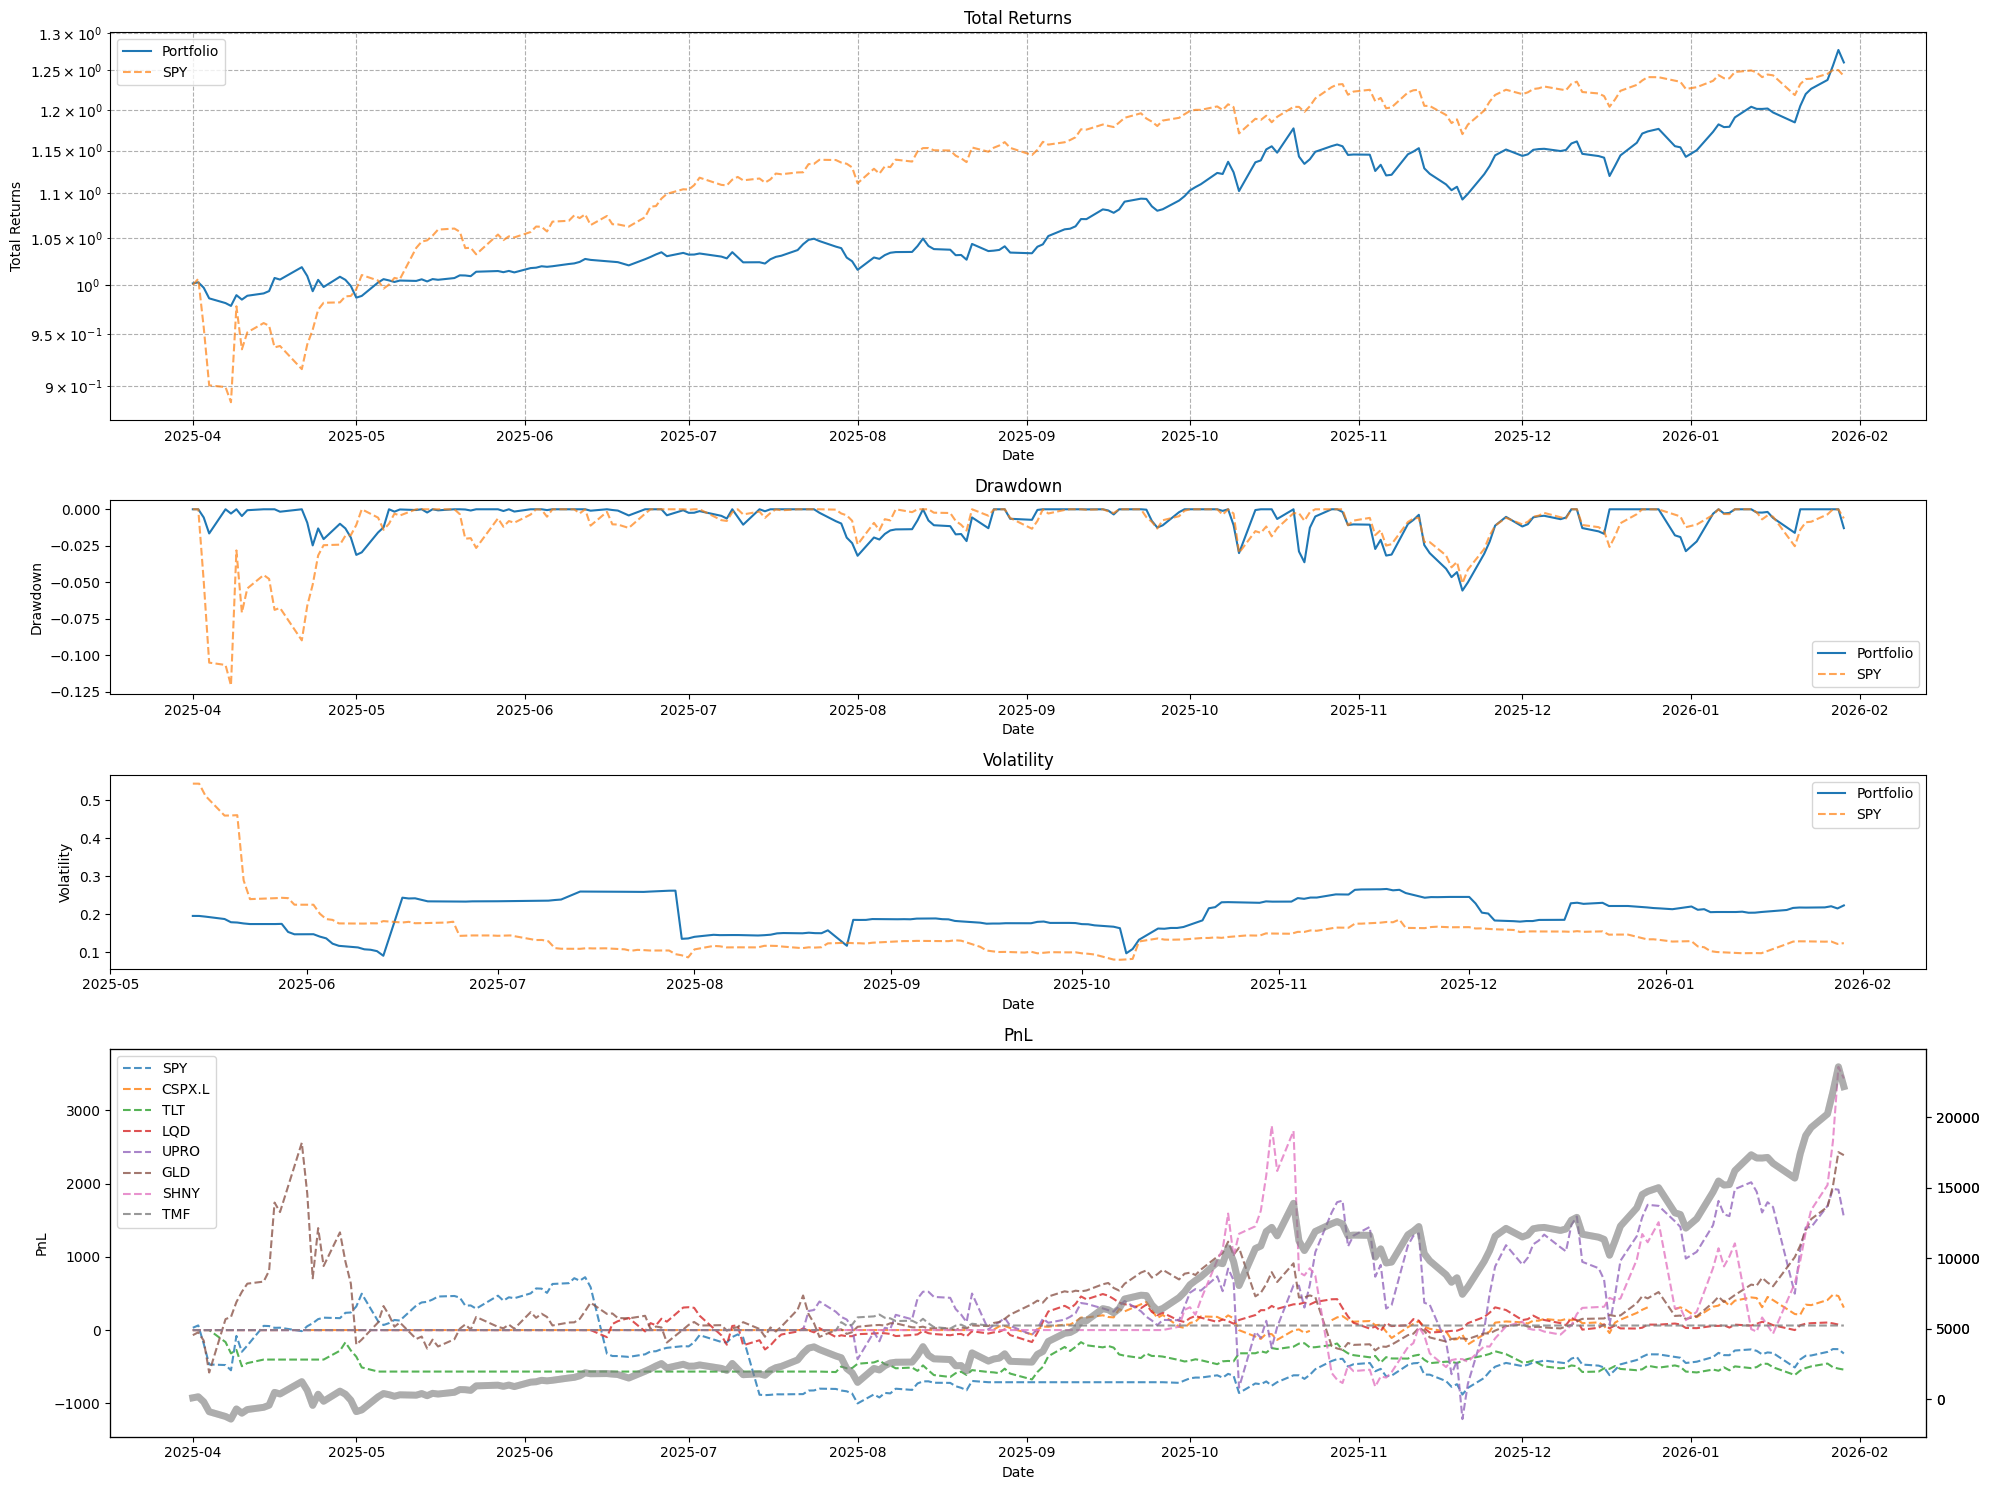

Index(['net_value', 'cash', 'capital', 'ABAT_position', 'ABAT_value',
       'ABAT_cost_basis', 'ABAT_realized_pnl', 'ABAT_price',
       'ABAT_unrealized_pnl', 'ABAT_total_pnl',
       ...
       'realized_pnl', 'unrealized_pnl', 'total_pnl', 'pnl', 'daily_returns',
       'volatility', 'SPY_total_returns', 'SPY_drawdown', 'SPY_daily_returns',
       'SPY_volatility'],
      dtype='object', length=211)

In [7]:
# All trades made
df_trade_list = pd.read_excel('./portfolio_tracker.xlsx')
df_trade_list['date'] = pd.to_datetime(df_trade_list['date']).dt.strftime('%Y-%m-%d')
df_trade_list

# Initialize Portfolio Tracker
ticker_list = list(df_trade_list['ticker'].unique())
ticker_list.sort()
ticker_list = [f for f in ticker_list if f in price_data.keys()]
portfolio_tracker = PortfolioTracker(price_data, tickers=ticker_list)

date_list = price_data['SPY'].index.strftime('%Y-%m-%d').to_list()
date_list = [d for d in date_list if d >= df_trade_list['date'].min()]
prev_date = price_data['SPY'].index.strftime('%Y-%m-%d').to_list()[0]
for date in tqdm(date_list):
    portfolio_tracker.current_date = date
    df = df_trade_list.loc[(df_trade_list['date'] > prev_date) & (df_trade_list['date'] <= date)]
    
    if 'CASH' in df['ticker'].values:
        cash_amount = df[df['ticker'] == 'CASH']['quantity'].values[0]
        portfolio_tracker.deposit_cash(cash_amount)
    
    for _, row in df.iterrows():
        ticker = row['ticker']
        if ticker == 'CASH':
            continue
        quantity = row['quantity']
        price = row['price']
        fees = row.get('fees', 0.0)  # Default to 0.0 if 'fees' column is not present
        portfolio_tracker.trade_asset(ticker, quantity, price, fees)
    
    
    portfolio_tracker.update_at_close()
    portfolio_tracker.record()

    prev_date = date
results_df, results_stats = portfolio_tracker.analyse(plot=True)
results_df.columns

# Strategy Testing

## Rebalance Trade
### Projected returns

0.222485673150716


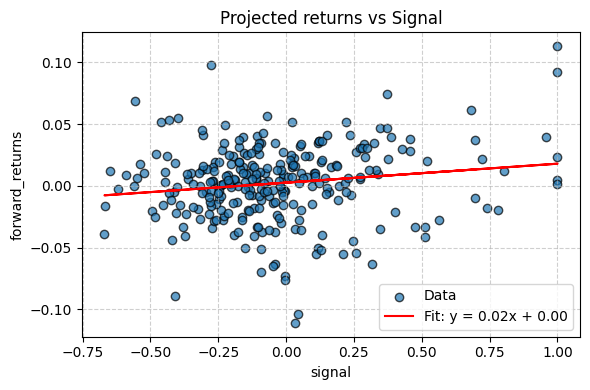

{'slope': np.float64(0.015337966915944527),
 'intercept': np.float64(0.0026407754242224043),
 'r_value': np.float64(0.1562777010805483),
 'p_value': np.float64(0.008807385939987596),
 'std_err': np.float64(0.005814056175282985)}

In [ ]:
# Rebalance trade -> front-run funds, wealth managers that rebalance at the end of the month.
# If SPY outperforms TLT in first 15 trading days of the month, go long SPY via UPRO.
# If TLT outperforms SPY in first 15 trading days of the month, go long TLT via TMF.

# Construct signal
spy_df = price_data['SPY'].copy()
tlt_df = price_data['TLT'].copy()

df = spy_df[['close']].rename(columns={'close': 'SPY_close'})
df['TLT_close'] = tlt_df['close']
df.dropna(inplace=True)
df['SPY_returns'] = np.log(df['SPY_close'] / df['SPY_close'].shift(1))
df['TLT_returns'] = np.log(df['TLT_close'] / df['TLT_close'].shift(1))
df = df[df.index >= '2002-08-01']

# Compute returns in first 15 trading days in month
df['month'] = df.index.to_series().dt.month
df['day_of_trading_month'] = df.groupby(df.index.to_series().dt.to_period("M")).cumcount() + 1
df['SPY_rolling_15d_returns'] = df['SPY_returns'].rolling(window=15).sum().shift(1)
df['TLT_rolling_15d_returns'] = df['TLT_returns'].rolling(window=15).sum().shift(1)
df['cont_signal'] = -(0.6 * (df['SPY_rolling_15d_returns'] + 1) / (0.6 * (df['SPY_rolling_15d_returns'] + 1) + 0.4 * (df['TLT_rolling_15d_returns'] + 1)) - 0.6)
ul = df['cont_signal'].quantile(0.95)
ll = abs(df['cont_signal'].quantile(0.05))

df['cont_signal'] = df['cont_signal'] * (0.5 / max(ul, ll))
df['cont_signal'] = df['cont_signal'].clip(lower=-1, upper=1)
abs_mean = df['cont_signal'].abs().mean()

print(abs_mean)
df['bin_signal'] = np.where(df['TLT_rolling_15d_returns'] > df['SPY_rolling_15d_returns'], 1, -1)

# Signal against forward returns
df_plot = df.copy()
df_plot['SPY_forward_returns'] = df_plot['SPY_returns'].rolling(window=6).sum().shift(-6)
df_plot['TLT_forward_returns'] = df_plot['TLT_returns'].rolling(window=6).sum().shift(-6)
df_plot['forward_returns_diff'] = df_plot['SPY_forward_returns'] - df_plot['TLT_forward_returns']
df_plot = df_plot.loc[df_plot['day_of_trading_month'] == 15]

df_plot = df_plot.dropna()
scatter_with_regression(
    df_plot['cont_signal'], 
    df_plot['forward_returns_diff'], 
    xlabel='signal', 
    ylabel='forward_returns', 
    title='Projected returns vs Signal'
)

# scatter_with_regression(
#     df_plot['bin_signal'], 
#     df_plot['forward_returns_diff'], 
#     xlabel='signal', 
#     ylabel='forward_returns', 
#     title='Projected returns vs Signal'
# )



### Backtest

  0%|          | 0/4030 [00:00<?, ?it/s]

Processing date: 2010-01-04
Processing date: 2010-01-05
Processing date: 2010-01-06
Processing date: 2010-01-07
Processing date: 2010-01-08
Processing date: 2010-01-11
Processing date: 2010-01-12
Processing date: 2010-01-13
Processing date: 2010-01-14
Processing date: 2010-01-15
Processing date: 2010-01-19
Processing date: 2010-01-20
Processing date: 2010-01-21
Processing date: 2010-01-22
Processing date: 2010-01-25
Processing date: 2010-01-26
Signal changed from 0.0 to 0.18911712122289837 on 2010-01-26
Open UPRO position
Trading 962 of UPRO at 1.965000033378601 with fees 0.0. Current position: 0, New position: 962
Processing date: 2010-01-27
Processing date: 2010-01-28
Processing date: 2010-01-29
Processing date: 2010-02-01
Signal changed from 0.4105204668519904 to 0.0 on 2010-02-01
Close all positions
Trading -962 of UPRO at 1.8995829820632935 with fees 0.0. Current position: 962, New position: 0
Realized PnL for this trade: -62.93 = quantity 962 * (price 1.8995829820632935 - cost_ba

,metric,Portfolio,SPY
0,Total Return,2.264820,7.162846
1,CAGR,0.052299,0.094677
2,Max Drawdown,-0.220147,-0.337173
3,Volatility,0.146953,0.171991
4,Sharpe Ratio,0.355891,0.550478


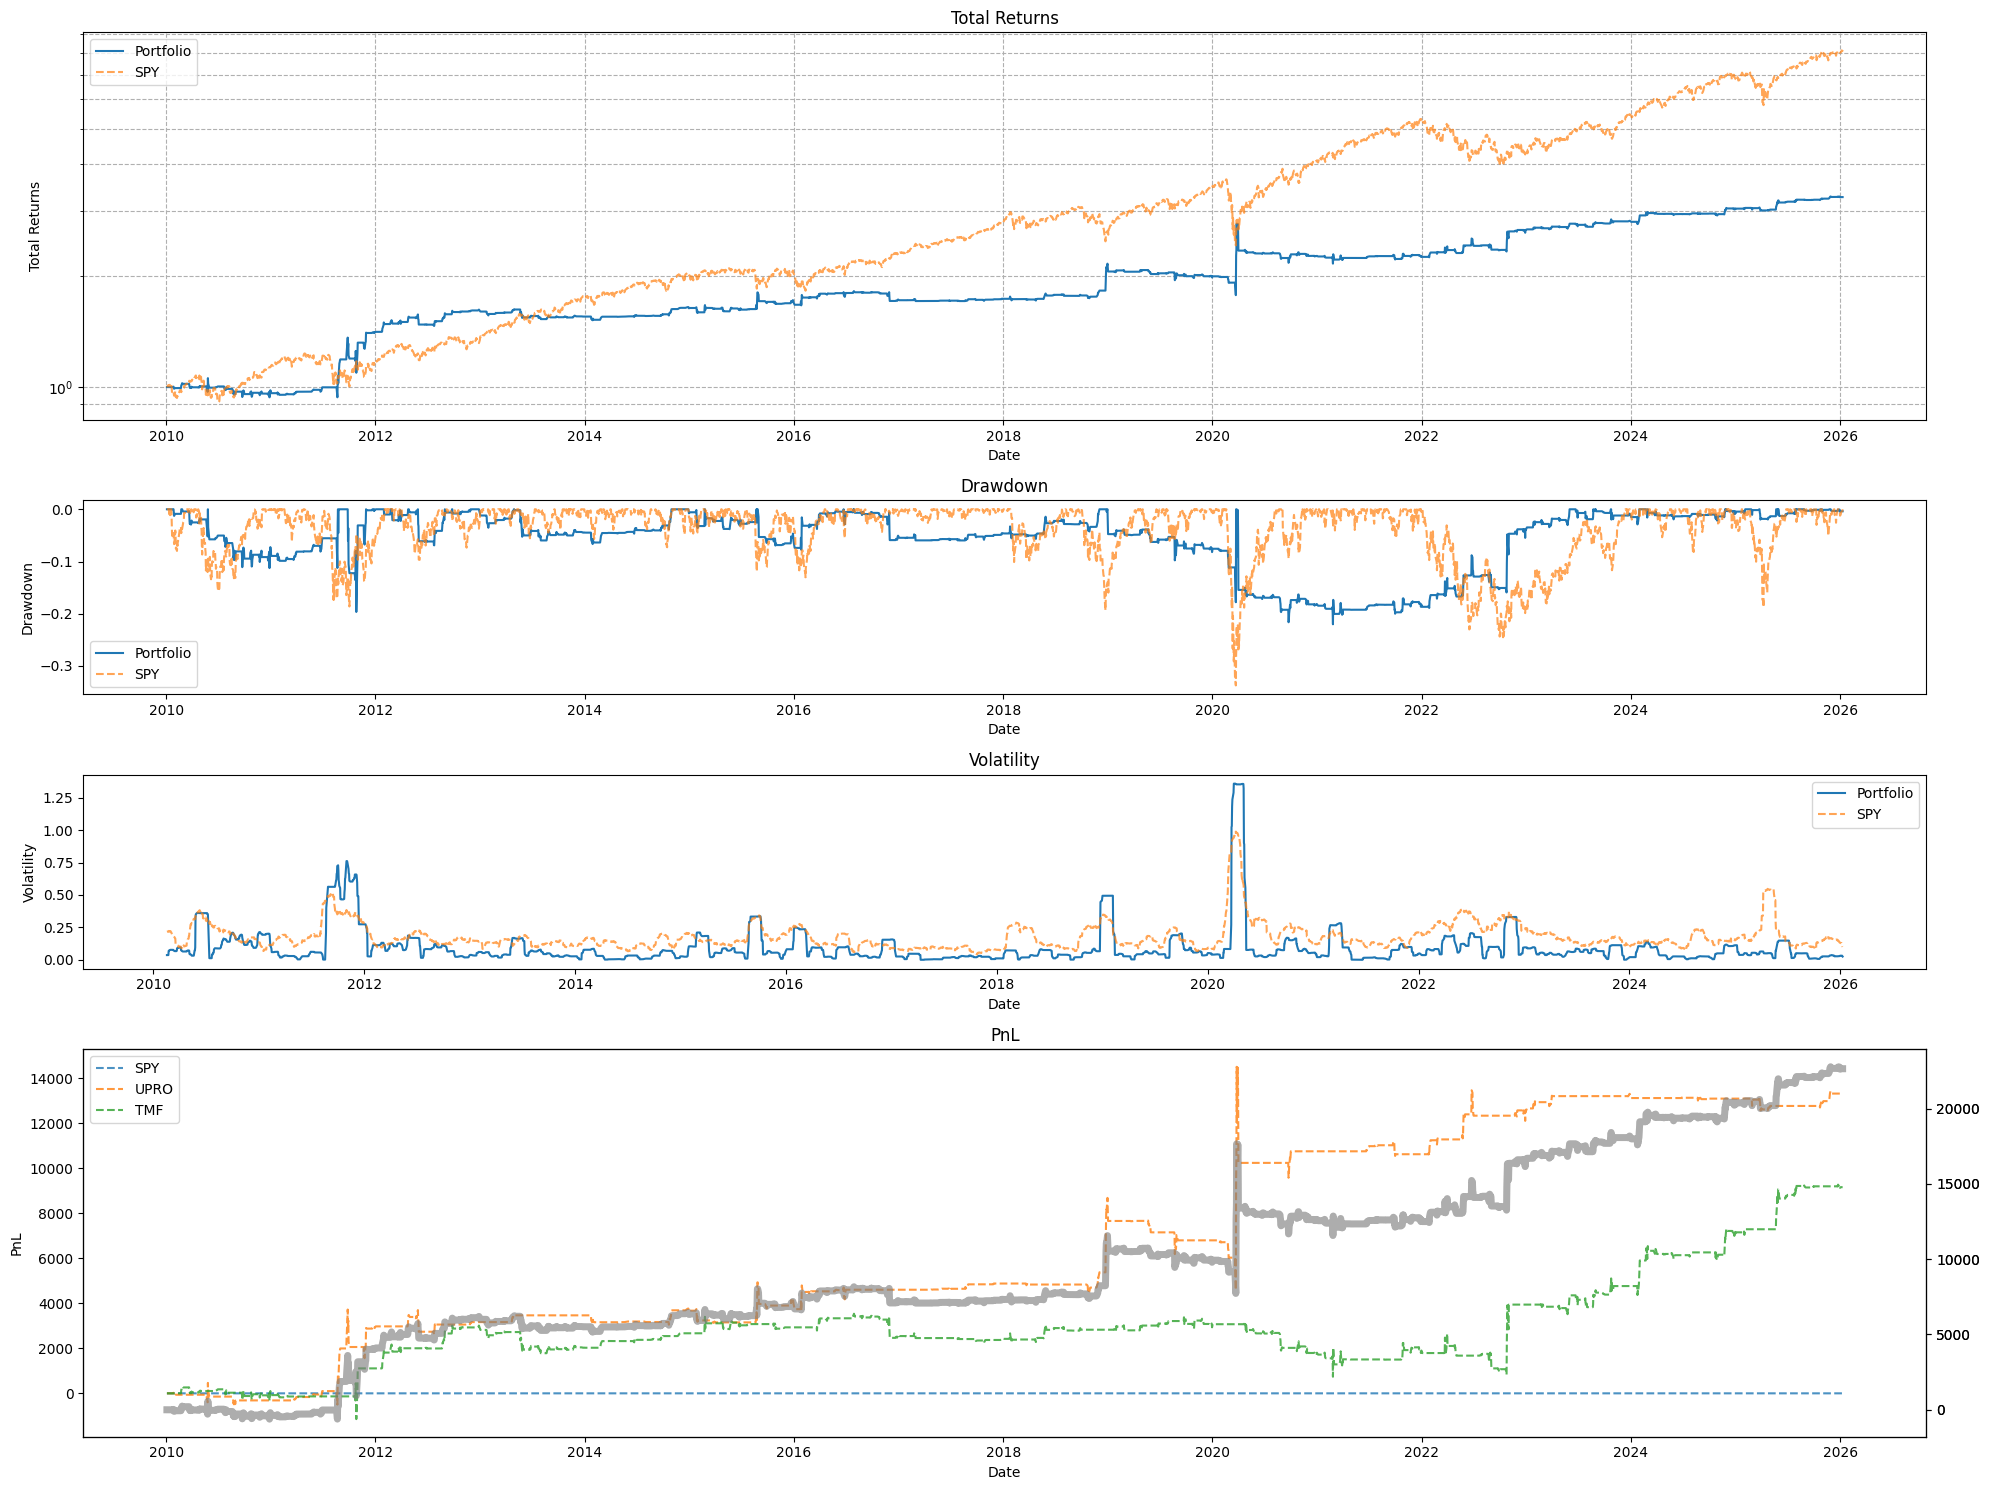

In [ ]:
df.loc[df['day_of_trading_month'] < 16, 'cont_signal'] = 0
df.loc[df['day_of_trading_month'] < 16, 'bin_signal'] = 0

price_data_rebalance = {
    'UPRO': price_data['UPRO'],
    'TMF': price_data['TMF'],
    'SPY': price_data['SPY'],
}
portfolio_tracker = PortfolioTracker(price_data_rebalance, tickers=['UPRO', 'TMF', 'SPY'])
portfolio_tracker.deposit_cash(10000)

date_list = price_data_rebalance['UPRO'].index
date_list = [d for d in date_list if d >= pd.to_datetime('2010-01-01')]

# Iterate through all dates in date_list
prev_signal = 0
for date in tqdm(date_list):
    print(f"Processing date: {date.strftime('%Y-%m-%d')}")
    portfolio_tracker.current_date = date.strftime('%Y-%m-%d')
    
    # prices
    upro_price = price_data_rebalance['UPRO'].loc[date]['open']
    tmf_price = price_data_rebalance['TMF'].loc[date]['open']
    cash = portfolio_tracker.portfolio.cash * 1
    
    signal = df.loc[date]['cont_signal']
    # signal = df.loc[date]['cont_signal']
    if prev_signal != signal and (prev_signal == 0 or signal == 0):
        print(f"Signal changed from {prev_signal} to {signal} on {date.strftime('%Y-%m-%d')}")
        if signal > 0:
            print("Open UPRO position")
            quantity = int(signal * cash / upro_price)
            portfolio_tracker.trade_asset('UPRO', quantity, upro_price)
        elif signal < 0:
            print("Open TMF position")
            quantity = int(-signal * cash / tmf_price)
            portfolio_tracker.trade_asset('TMF', quantity, tmf_price)
        elif signal == 0:
            print("Close all positions")
            # Close all positions
            upro_position = portfolio_tracker.portfolio.asset_positions['UPRO']
            tmf_position = portfolio_tracker.portfolio.asset_positions['TMF']
            if upro_position != 0:
                portfolio_tracker.trade_asset('UPRO', -upro_position, upro_price)
            if tmf_position != 0:
                portfolio_tracker.trade_asset('TMF', -tmf_position, tmf_price)
    
    
    
    prev_signal = signal
    portfolio_tracker.update_at_close()
    # print(portfolio_tracker.portfolio.asset_positions, portfolio_tracker.portfolio.asset_values)
    portfolio_tracker.record()

    prev_date = date
df_results, stats_results = portfolio_tracker.analyse(plot=True)


In [ ]:
df_ret = portfolio_tracker.history.copy()
df_ret['21d_returns'] = df_ret['net_value'].pct_change(periods=21)
# Record monthly returns at the start of each month
df_ret['month'] = df_ret.index.to_series().dt.month
prev_month = 0
monthly_returns = []
for i, r in df_ret.iterrows():
    month = r['month']
    if prev_month != month and not np.isnan(r['21d_returns']):
        monthly_returns.append(r['21d_returns'])
        prev_month = month

print(monthly_returns)

[np.float64(-0.0062931203365326205), np.float64(0.024254017532266747), np.float64(-0.02095089586829124), np.float64(0.005848260950308992), np.float64(-0.009985825108913216), np.float64(0.007691884869371224), np.float64(-0.015121891260691966), np.float64(-0.01709443700759883), np.float64(-0.014993416754416788), np.float64(0.008148825086292444), np.float64(-0.004883461719185411), np.float64(0.0024399154049479232), np.float64(-0.028272937027821965), np.float64(-0.005697580664249746), np.float64(0.015567134346891498), np.float64(0.004238234894275106), np.float64(0.011614216322686222), np.float64(0.015577414587244931), np.float64(-2.622030612631221e-07), np.float64(0.1901148216212134), np.float64(0.005364146139372972), np.float64(0.10420912890940093), np.float64(0.06203419086704964), np.float64(0.007039715996200568), np.float64(0.055030619777637346), np.float64(-0.00710289284827903), np.float64(0.010041139910079266), np.float64(0.039709055607238586), np.float64(-0.04251134686905145), np.flo

{'mean': np.float64(0.00637097734889399),
 'std': np.float64(0.030404043544615417),
 'skew': np.float64(3.8852678583040245)}

  0%|          | 0/201 [00:00<?, ?it/s]

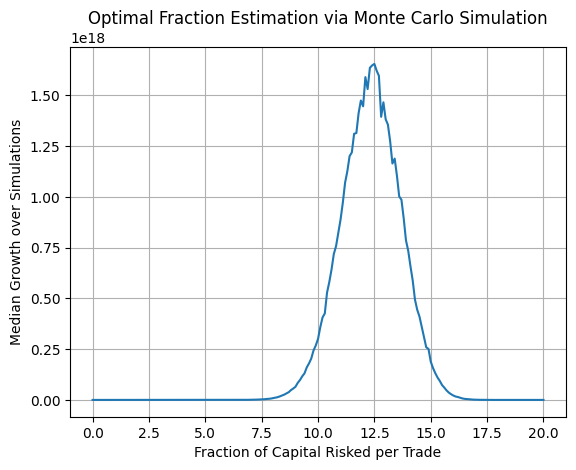

{'optimal_fraction': np.float64(12.5),
 'growth_rates': array([[0.00000000e+00, 0.00000000e+00],
        [1.00000000e-01, 1.13153586e+00],
        [2.00000000e-01, 3.49147721e+00],
        [3.00000000e-01, 8.37334746e+00],
        [4.00000000e-01, 1.83408366e+01],
        [5.00000000e-01, 3.86057621e+01],
        [6.00000000e-01, 7.87820377e+01],
        [7.00000000e-01, 1.58793806e+02],
        [8.00000000e-01, 3.14981228e+02],
        [9.00000000e-01, 6.19288808e+02],
        [1.00000000e+00, 1.20269087e+03],
        [1.10000000e+00, 2.34031166e+03],
        [1.20000000e+00, 4.45474458e+03],
        [1.30000000e+00, 8.44471744e+03],
        [1.40000000e+00, 1.57475381e+04],
        [1.50000000e+00, 2.95612235e+04],
        [1.60000000e+00, 5.45773319e+04],
        [1.70000000e+00, 1.01144136e+05],
        [1.80000000e+00, 1.80837223e+05],
        [1.90000000e+00, 3.22280120e+05],
        [2.00000000e+00, 5.78382244e+05],
        [2.10000000e+00, 1.02222262e+06],
        [2.20000000e+

In [ ]:
import numpy as np
from scipy import stats

def fit_and_sample(data, n_samples=1000, method='parametric'):
    """
    Fit a distribution to data and produce random samples.
    
    Parameters
    ----------
    data : array-like
        Input array of numbers.
    n_samples : int, optional
        Number of samples to generate, default is 1000.
    method : {'parametric', 'nonparametric'}, optional
        Sampling method:
            - 'parametric': fit a normal distribution (mean, std, skew).
            - 'nonparametric': resample directly from data with replacement.
    
    Returns
    -------
    dict
        Dictionary with:
        - 'fit_params': dict of fitted parameters (mean, std, skew)
        - 'samples': generated random samples (numpy array)
    """
    data = np.asarray(data)
    if len(data) < 2:
        raise ValueError("Data must contain at least two values.")
    
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    skew = stats.skew(data)
    
    if method == 'parametric':
        # Fit a normal distribution (skew not used directly in sampling)
        samples = np.random.normal(loc=mean, scale=std, size=n_samples)
    elif method == 'nonparametric':
        # Bootstrap-style resampling from the data
        samples = np.random.choice(data, size=n_samples, replace=True)
    else:
        raise ValueError("method must be 'parametric' or 'nonparametric'.")
    
    return {
        'fit_params': {'mean': mean, 'std': std, 'skew': skew},
        'samples': samples
    }


result = fit_and_sample(monthly_returns, n_samples=5000, method='nonparametric')
display(result['fit_params'])



def optimal_fraction_montecarlo(returns, n_trials=10000, sequence_length=100, max_fraction=1.0, resolution=0.001, random_state=None):
    """
    Estimate the optimal fraction of capital to risk on a trade via Monte Carlo simulation.
    
    Parameters
    ----------
    returns : array-like
        Array of possible trade returns (e.g., +0.05 for +5%, -0.02 for -2%).
        These represent the *percentage change per trade* (not absolute P/L).
    n_trials : int, optional
        Number of Monte Carlo sequences to simulate, default is 10,000.
    capital : float, optional
        Starting capital for each simulation, default is 1.0.
    max_fraction : float, optional
        Maximum fraction of capital to consider risking per trade, default is 1.0.
    resolution : float, optional
        Step size for testing different fractions, default is 0.001 (0.1% increments).
    random_state : int, optional
        Random seed for reproducibility.
    
    Returns
    -------
    dict
        Dictionary with:
        - 'optimal_fraction': fraction of capital that maximizes geometric mean growth
        - 'growth_rates': array of (fraction, avg_growth_rate)
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    returns = np.asarray(returns)
    if np.any(returns <= -1):
        raise ValueError("Returns must be greater than -1 (cannot lose more than 100%).")

    fractions = np.arange(0, max_fraction + resolution, resolution)
    growth_rates = []

    for f in tqdm(fractions):
        # Simulate capital growth over many random trade sequences
        # Each trial multiplies capital over many sampled returns
        sampled_returns = np.random.choice(returns, size=(n_trials, sequence_length), replace=True)

        # calculate geometric growth for each trial through the sequence
        # value = (1 - f) * 1 + f * (1 + r) = 1 + f * r
        growth = np.prod(1 + f * (sampled_returns), axis=1)


        # plt.hist(growth, bins=50)
        # plt.title(f'Histogram of final capital for fraction {f:.3f}')
        # plt.xlabel('Final Capital')
        # plt.ylabel('Frequency')
        # plt.show()
        # average log growth rate across all trials
        avg_log_growth = np.median(growth - 1)
        # print(f"Fraction: {f:.3f}, Avg Growth: {avg_log_growth:.6f}")
        growth_rates.append(avg_log_growth)
    
    growth_rates = np.array(growth_rates)
    plt.plot(fractions, growth_rates)
    plt.xlabel('Fraction of Capital Risked per Trade')
    plt.ylabel('Median Growth over Simulations')
    plt.title('Optimal Fraction Estimation via Monte Carlo Simulation')
    plt.grid(True)
    plt.show()
    optimal_fraction = fractions[np.argmax(growth_rates)]
    
    return {
        'optimal_fraction': optimal_fraction,
        'growth_rates': np.column_stack((fractions, growth_rates))
    }

result = optimal_fraction_montecarlo(monthly_returns, n_trials=100000, sequence_length=1200, max_fraction=20.0, resolution=0.1, random_state=42)
result

## 2. Momentum Trade

### SPY vs rolling returns

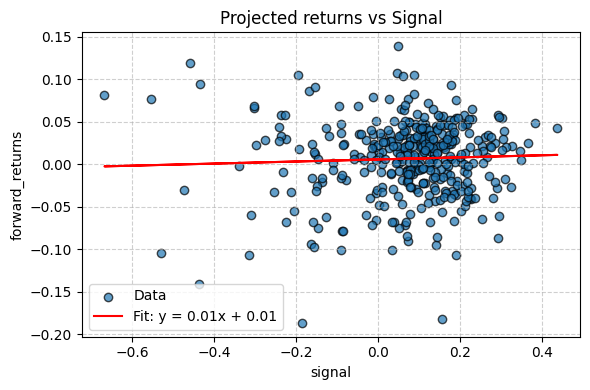

{'slope': np.float64(0.012206151567101293),
 'intercept': np.float64(0.005575208017337153),
 'r_value': np.float64(0.04290603849175505),
 'p_value': np.float64(0.40240779613793864),
 'std_err': np.float64(0.014561218931874459)}

In [ ]:
# Momentum Trade
# If previous return > 0, go long SPY
# If previous return < 0, go to cash

# Construct signal
spy_df = price_data['SPY'].copy()

# Settings
lookback_period = 252 - 21
lag_period = 21

# Compute returns based on lookback and lag
df = spy_df[['close']].rename(columns={'close': 'SPY_close'})
df['SPY_returns_252d'] = np.log(df['SPY_close'] / df['SPY_close'].shift(lookback_period)).shift(lag_period)
df['SPY_returns'] = np.log(df['SPY_close'] / df['SPY_close'].shift(1))
df['SPY_forward_monthly_returns'] = df['SPY_returns'].rolling(window=21).sum().shift(-21)


df_plot = df.copy()
df_plot['day_of_trading_month'] = df.groupby(df.index.to_series().dt.to_period("M")).cumcount() + 1
df_plot = df_plot.loc[df_plot['day_of_trading_month'] == 1]
df_plot = df_plot.dropna()
scatter_with_regression(
    df_plot['SPY_returns_252d'], 
    df_plot['SPY_forward_monthly_returns'], 
    xlabel='signal', 
    ylabel='forward_returns', 
    title='Projected returns vs Signal'
)


### UPRO vs rolling returns

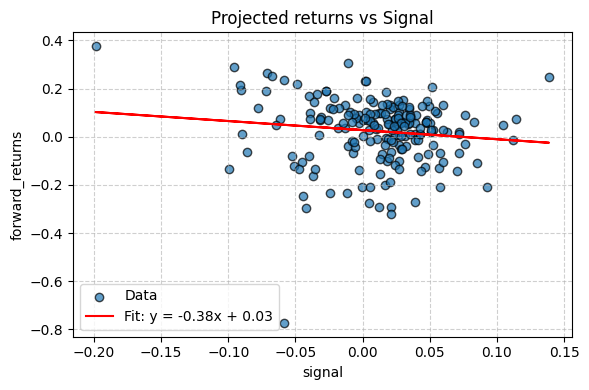

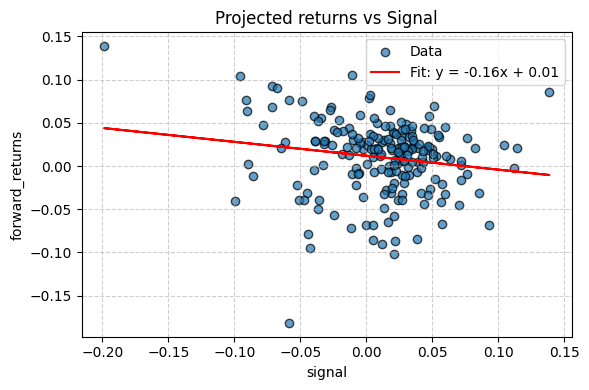

{'slope': np.float64(-0.16094804087481027),
 'intercept': np.float64(0.01188860709873365),
 'r_value': np.float64(-0.16384722966826182),
 'p_value': np.float64(0.021080074700251177),
 'std_err': np.float64(0.06921645638475508)}

In [ ]:
# Momentum Trade
# If previous return > 0, go long SPY
# If previous return < 0, go to cash

# Construct signal
spy_df = price_data['SPY'].copy()
vix_df = price_data['^VIX'].copy()
upro_df = price_data['UPRO'].copy()

# Settings
lookback_period = 21
lag_period = 0

# Compute returns based on lookback and lag
df = spy_df[['close']].rename(columns={'close': 'SPY_close'})
df['SPY_returns_252d'] = np.log(df['SPY_close'] / df['SPY_close'].shift(lookback_period)).shift(lag_period)
df['SPY_returns'] = np.log(df['SPY_close'] / df['SPY_close'].shift(1))
df['SPY_forward_monthly_returns'] = df['SPY_returns'].rolling(window=21).sum().shift(-21)
df['UPRO_close'] = upro_df['close']
df['UPRO_forward_monthly_returns'] = np.log(df['UPRO_close'] / df['UPRO_close'].shift(21)).shift(-21)


df_plot = df.copy()
df_plot['day_of_trading_month'] = df.groupby(df.index.to_series().dt.to_period("M")).cumcount() + 1
df_plot = df_plot.loc[df_plot['day_of_trading_month'] == 1]
df_plot = df_plot.dropna()
scatter_with_regression(
    df_plot['SPY_returns_252d'], 
    df_plot['UPRO_forward_monthly_returns'], 
    xlabel='signal', 
    ylabel='forward_returns', 
    title='Projected returns vs Signal'
)
scatter_with_regression(
    df_plot['SPY_returns_252d'], 
    df_plot['SPY_forward_monthly_returns'], 
    xlabel='signal', 
    ylabel='forward_returns', 
    title='Projected returns vs Signal'
)

### UPRO vs VIX

0.553624808974446 -0.01563415674630529


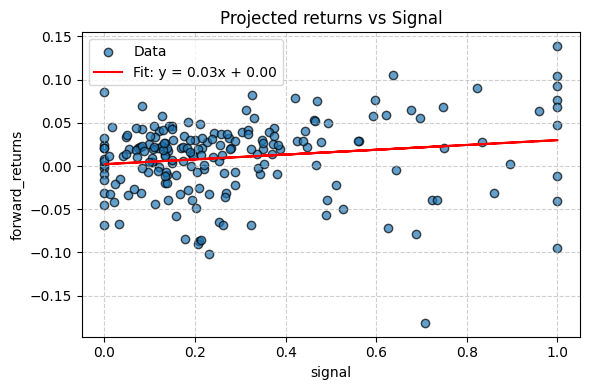

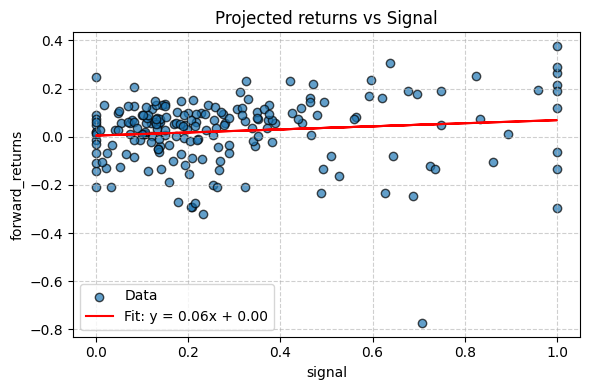

{'slope': np.float64(0.06387047567745704),
 'intercept': np.float64(0.004697951475926148),
 'r_value': np.float64(0.1203525884980132),
 'p_value': np.float64(0.09123225822337437),
 'std_err': np.float64(0.0376312249141068)}

In [ ]:
# Construct signal
spy_df = price_data['SPY'].copy()
vix_df = price_data['^VIX'].copy()
upro_df = price_data['UPRO'].copy()

# Settings
lookback_period = 21
lag_period = 0

# Compute returns based on lookback and lag
df = spy_df[['close']].rename(columns={'close': 'SPY_close'})
df['SPY_returns_252d'] = np.log(df['SPY_close'] / df['SPY_close'].shift(lookback_period)).shift(lag_period)
df['SPY_returns'] = np.log(df['SPY_close'] / df['SPY_close'].shift(1))
df['SPY_forward_monthly_returns'] = df['SPY_returns'].rolling(window=21).sum().shift(-21)
df['UPRO_close'] = upro_df['close']
df['UPRO_forward_monthly_returns'] = np.log(df['UPRO_close'] / df['UPRO_close'].shift(21)).shift(-21)
df['vix'] = vix_df['close']
df['vix_21d_ma'] = df['vix'].rolling(window=21).mean()
df['signal'] = df['vix_21d_ma'] * (df['SPY_returns_252d'] * -0.16 + 0.01)
print(df['signal'].quantile(0.95), df['signal'].quantile(0.05))
df['signal'] = df['signal'] * (1.0 / max(abs(df['signal'].quantile(0.95)), abs(df['signal'].quantile(0.05))))
df['signal'] = df['signal'].clip(lower=0.0, upper=1.0)

df_plot = df.copy()
df_plot['day_of_trading_month'] = df.groupby(df.index.to_series().dt.to_period("M")).cumcount() + 1
df_plot = df_plot.loc[df_plot['day_of_trading_month'] == 1]
df_plot = df_plot.dropna()
scatter_with_regression(
    df_plot['signal'], 
    df_plot['SPY_forward_monthly_returns'], 
    xlabel='signal', 
    ylabel='forward_returns', 
    title='Projected returns vs Signal'
)
scatter_with_regression(
    df_plot['signal'], 
    df_plot['UPRO_forward_monthly_returns'], 
    xlabel='signal', 
    ylabel='forward_returns', 
    title='Projected returns vs Signal'
)


## Backtest

32.72366645449682 11.596952374776205


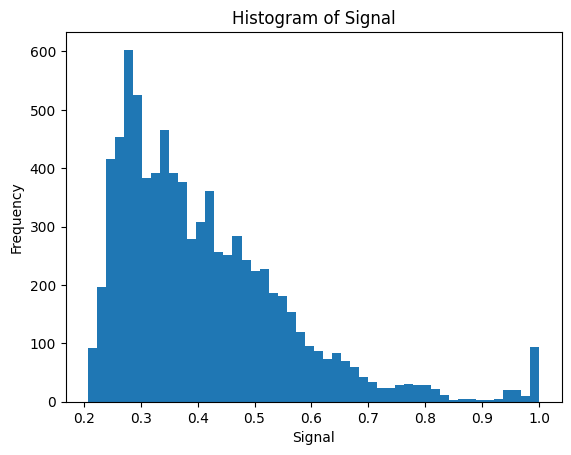

  0%|          | 0/4030 [00:00<?, ?it/s]

Trading 0 of UPRO at 2.147083044052124 with fees 0.0. Current position: 0, New position: 0
Trading 2320 of UPRO at 1.8995829820632935 with fees 0.0. Current position: 0, New position: 2320
Trading 76 of UPRO at 2.0470829010009766 with fees 0.0. Current position: 2320, New position: 2396
Trading -699 of UPRO at 2.4598610401153564 with fees 0.0. Current position: 2396, New position: 1697
Realized PnL for this trade: -388.36 = quantity -699 * (price 2.4598610401153564 - cost_basis 1.90 = 0.56)
Trading -27 of UPRO at 2.5427780151367188 with fees 0.0. Current position: 1697, New position: 1670
Realized PnL for this trade: -17.24 = quantity -27 * (price 2.5427780151367188 - cost_basis 1.90 = 0.64)
Trading 2161 of UPRO at 1.8477779626846313 with fees 0.0. Current position: 1670, New position: 3831
Trading -130 of UPRO at 1.5876389741897583 with fees 0.0. Current position: 3831, New position: 3701
Realized PnL for this trade: 37.02 = quantity -130 * (price 1.5876389741897583 - cost_basis 1.87 

,metric,Portfolio,SPY
0,Total Return,12.076672,7.162846
1,CAGR,0.117129,0.094677
2,Max Drawdown,-0.374481,-0.337173
3,Volatility,0.240061,0.171991
4,Sharpe Ratio,0.487915,0.550478


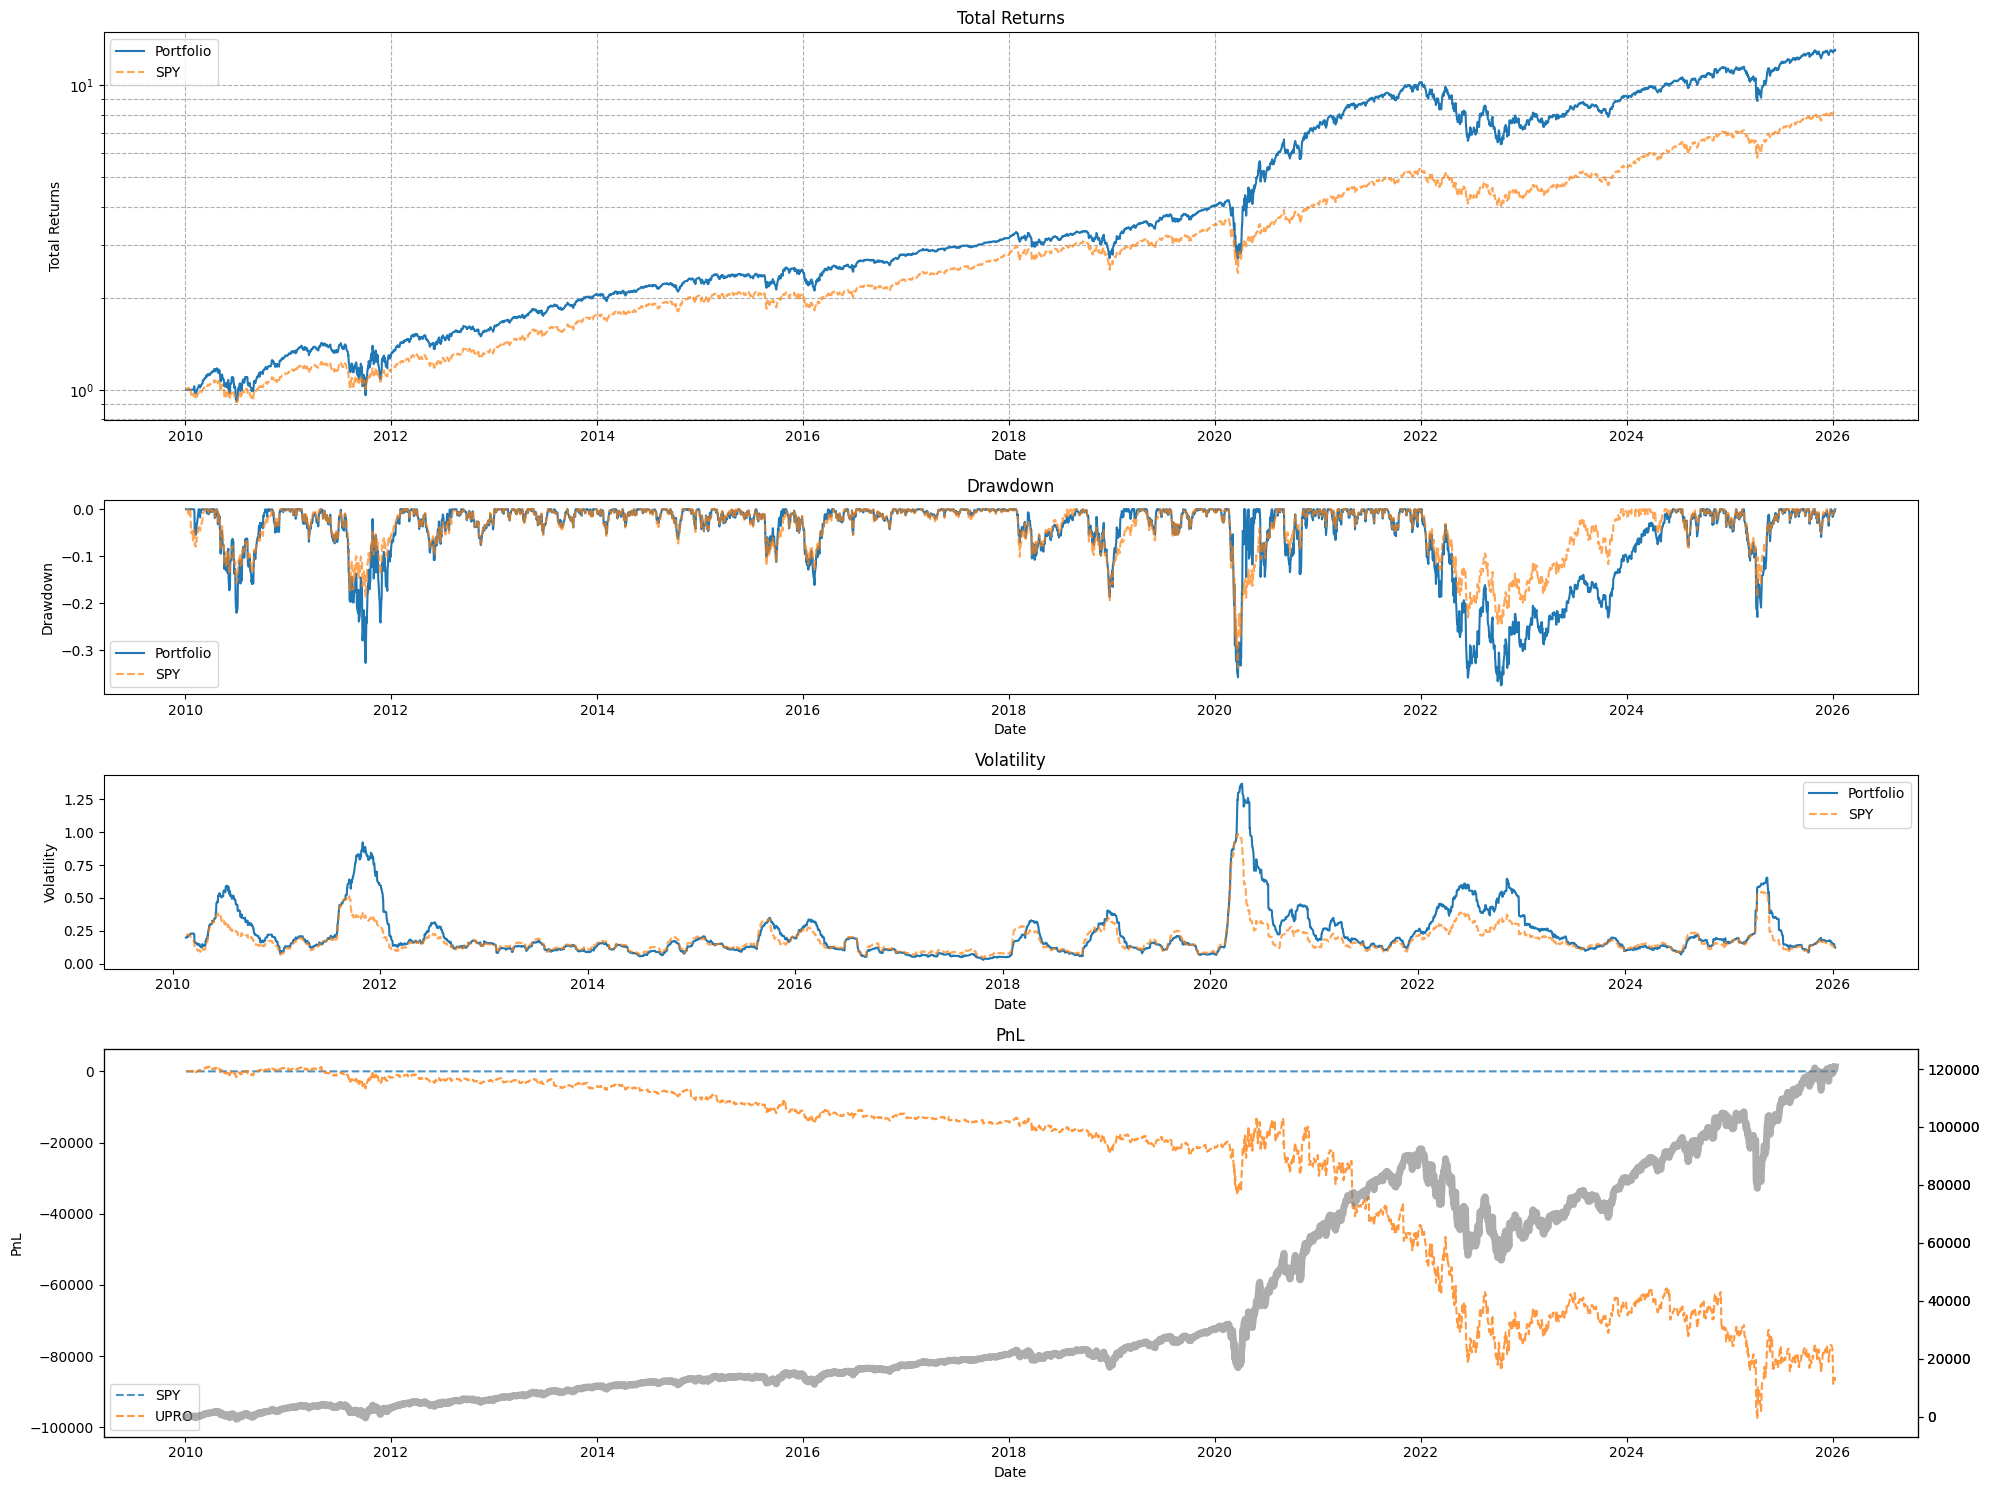

In [ ]:
# Construct signal
spy_df = price_data['SPY'].copy()
vix_df = price_data['^VIX'].copy()
upro_df = price_data['UPRO'].copy()

# Settings
lookback_period = 21
lag_period = 0

# Compute returns based on lookback and lag
df = spy_df[['close']].rename(columns={'close': 'SPY_close'})
df['SPY_returns_252d'] = np.log(df['SPY_close'] / df['SPY_close'].shift(lookback_period)).shift(lag_period)
df['SPY_returns'] = np.log(df['SPY_close'] / df['SPY_close'].shift(1))
df['SPY_forward_monthly_returns'] = df['SPY_returns'].rolling(window=21).sum().shift(-21)
df['UPRO_close'] = upro_df['close']
df['UPRO_forward_monthly_returns'] = np.log(df['UPRO_close'] / df['UPRO_close'].shift(21)).shift(-21)
df['vix'] = vix_df['close']
df['vix_21d_ma'] = df['vix'].rolling(window=21).mean()
df['signal'] = df['vix_21d_ma']
print(df['signal'].quantile(0.95), df['signal'].quantile(0.05))
df['signal'] = df['signal'] * (1.0 / max(abs(df['signal'].quantile(0.99)), abs(df['signal'].quantile(0.05))))
df['signal'] = df['signal'].clip(lower=0.0, upper=1.0)

plt.hist(df['signal'].dropna(), bins=50)
plt.title('Histogram of Signal')
plt.xlabel('Signal')
plt.ylabel('Frequency')
plt.show()

df['day_of_trading_month'] = df.groupby(df.index.to_series().dt.to_period("M")).cumcount() + 1
df.loc[df['day_of_trading_month'] != 1, 'signal'] = 0

price_data_rebalance = {
    'UPRO': price_data['UPRO'],
    'SPY': price_data['SPY'],
}
portfolio_tracker = PortfolioTracker(price_data_rebalance, tickers=['UPRO', 'SPY'])
portfolio_tracker.deposit_cash(10000)

date_list = price_data_rebalance['UPRO'].index
date_list = [d for d in date_list if d >= pd.to_datetime('2010-01-01')]

# Iterate through all dates in date_list
for date in tqdm(date_list):
    portfolio_tracker.current_date = date.strftime('%Y-%m-%d')
    
    # prices
    upro_price = price_data_rebalance['UPRO'].loc[date]['open']
    cash = portfolio_tracker.portfolio.cash
    
    signal = df.loc[date]['signal']
    # signal = 1.0
    
    if signal > 0:
        target_quantity = int(signal * portfolio_tracker.portfolio.net_value / upro_price)
        trade_quantity = target_quantity - portfolio_tracker.portfolio.asset_positions['UPRO']
        portfolio_tracker.trade_asset('UPRO', trade_quantity, upro_price)
            
    portfolio_tracker.update_at_close()
    # print(portfolio_tracker.portfolio.asset_positions, portfolio_tracker.portfolio.asset_values)
    portfolio_tracker.record()

    prev_date = date
df_results, stats_results = portfolio_tracker.analyse(plot=True)


## Current Holdings

In [ ]:
current_holdings = {
    ticker: holdings[ticker].iloc[-1] for ticker in holdings if holdings[ticker].iloc[-1] != 0
}

current_holdings
df_view = pd.DataFrame.from_dict(current_holdings, orient='index', columns=['quantity'])
df_view['price'] = [price_data_dict[ticker]['close'].iloc[-1] for ticker in df_view.index]
df_view['value'] = df_view['quantity'] * df_view['price']
df_view['% of portfolio'] = df_view['value'] / CURRENT_CAPITAL * 100
df_view.sort_values('value', ascending=False, inplace=True)
print(f"% of portfolio: {sum(df_view['% of portfolio']):.2f}%")
df_view

NameError: name 'holdings' is not defined

# Factor Study

## Momentum

  0%|          | 0/999 [00:00<?, ?it/s]

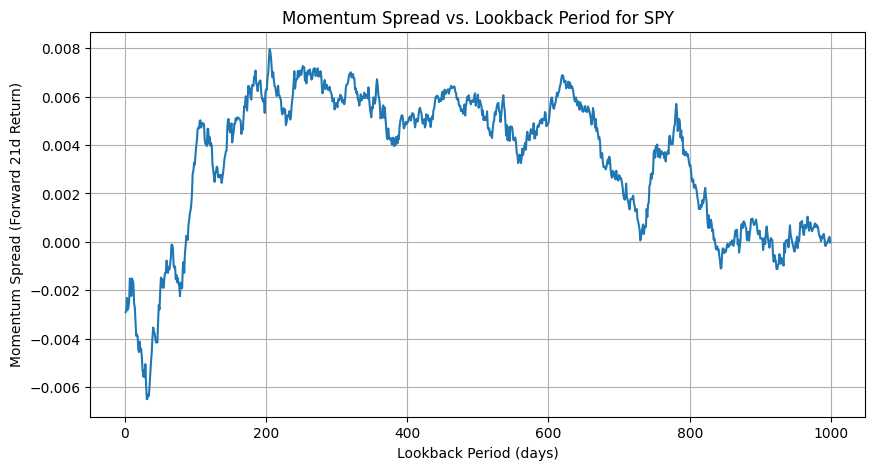

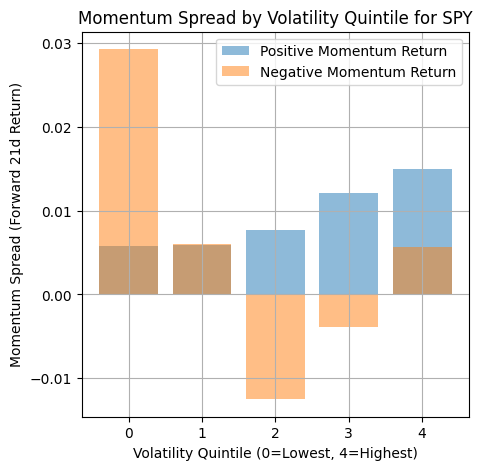

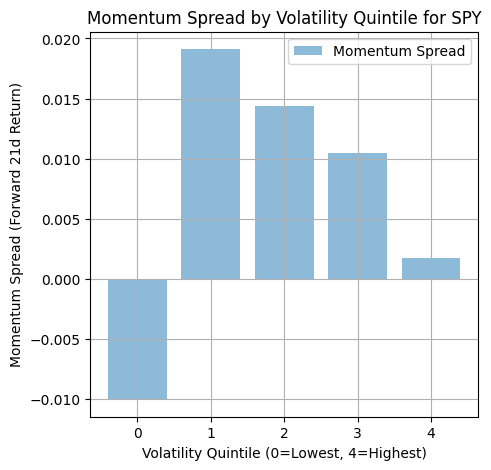

  0%|          | 0/999 [00:00<?, ?it/s]

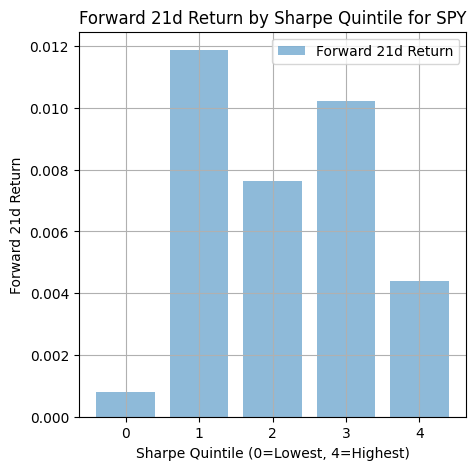

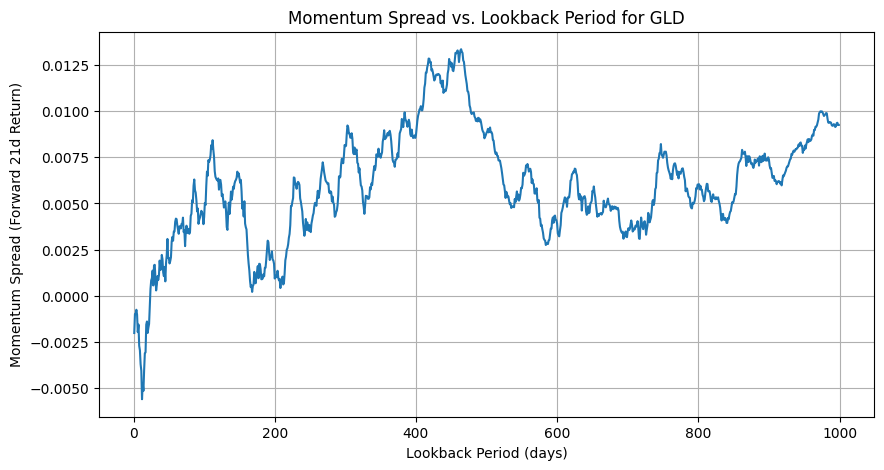

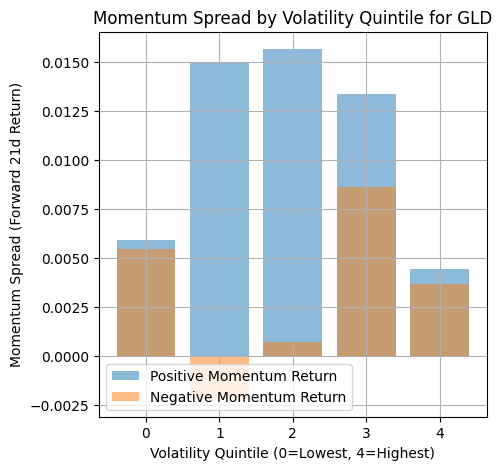

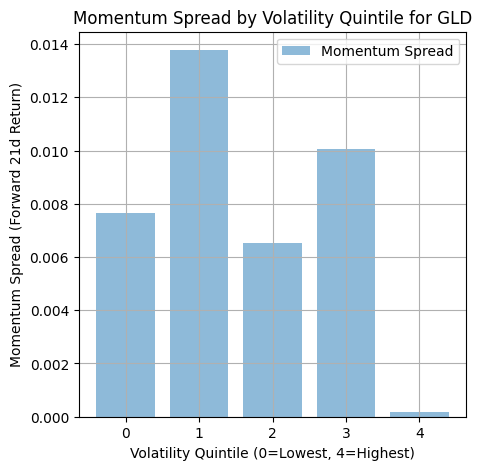

  0%|          | 0/999 [00:00<?, ?it/s]

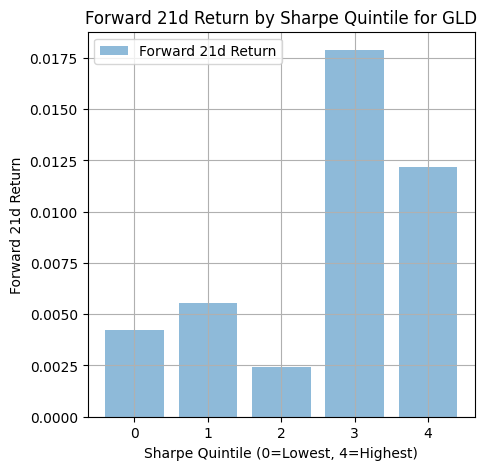

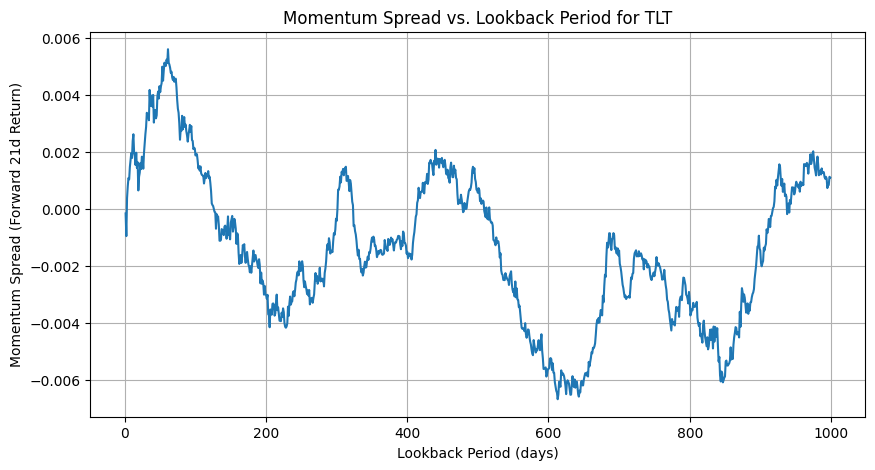

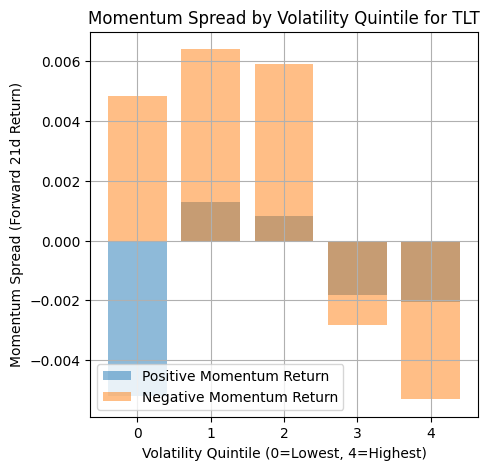

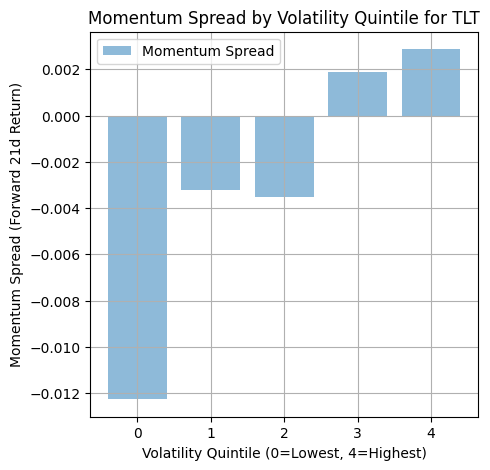

  0%|          | 0/999 [00:00<?, ?it/s]

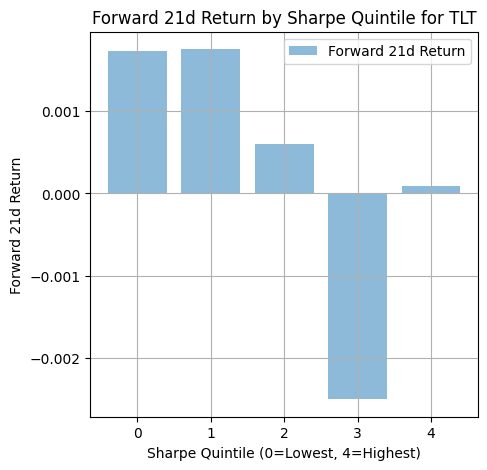

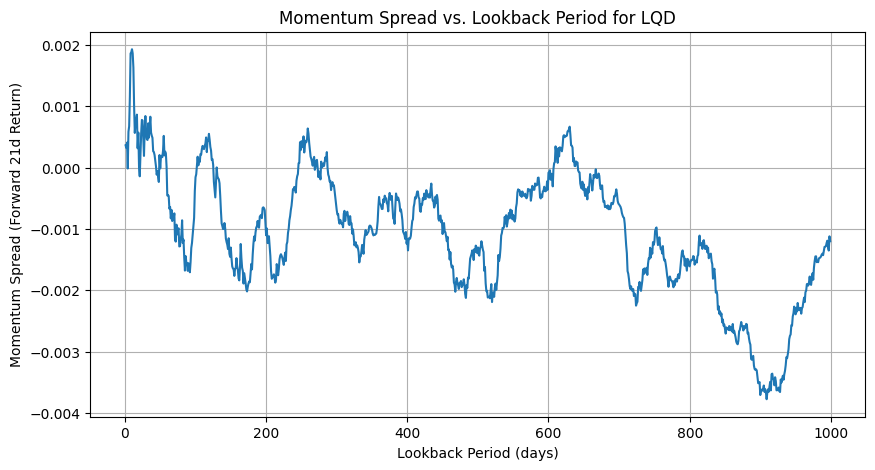

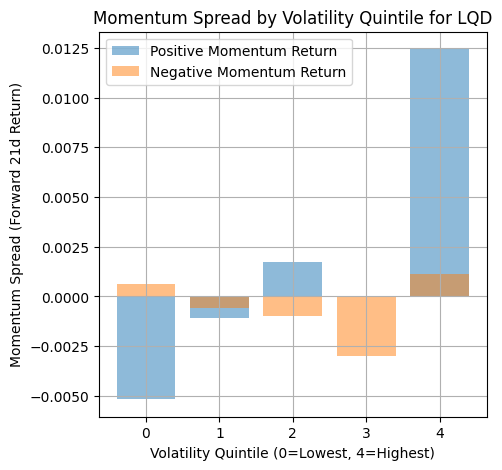

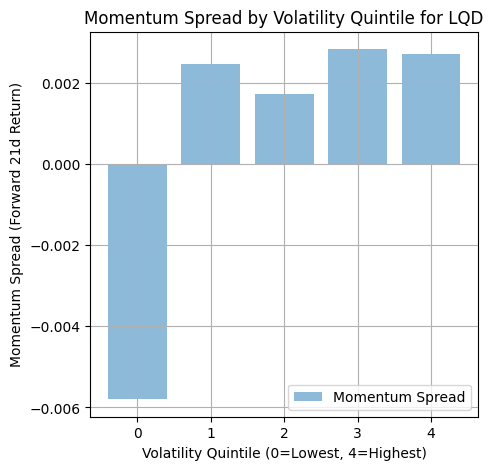

  0%|          | 0/999 [00:00<?, ?it/s]

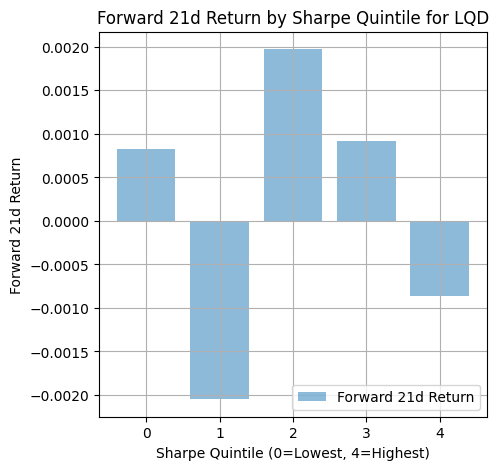

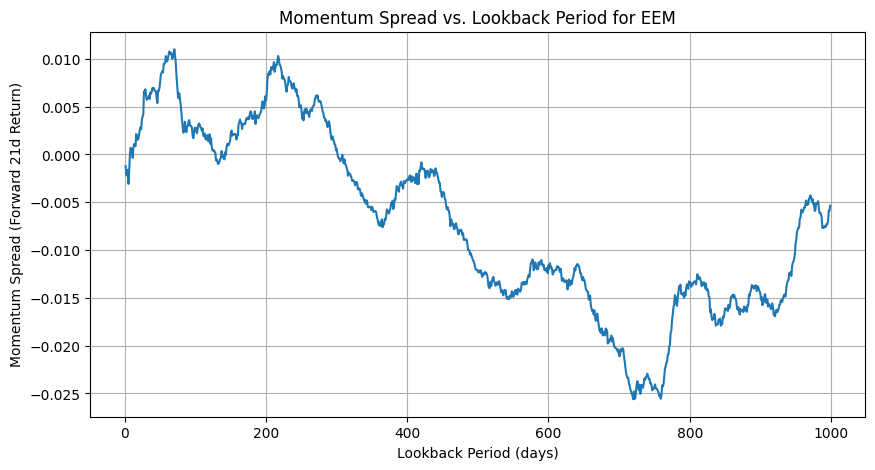

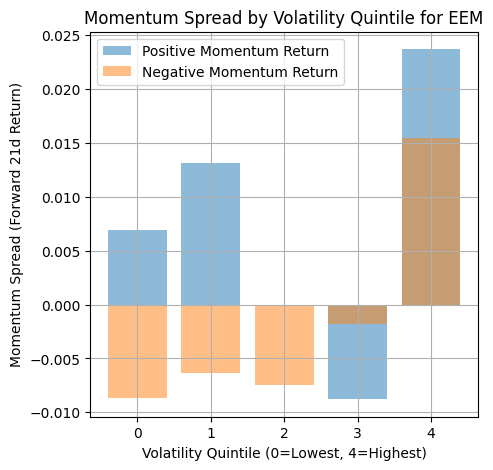

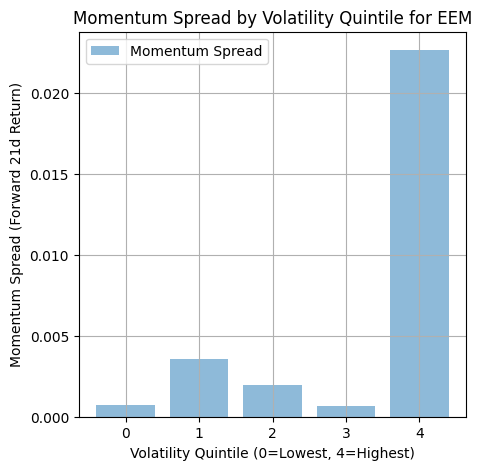

  0%|          | 0/999 [00:00<?, ?it/s]

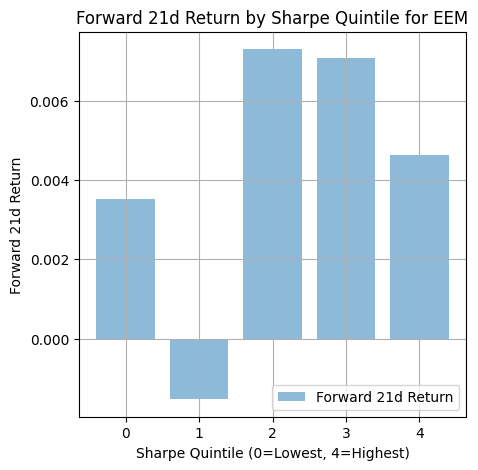

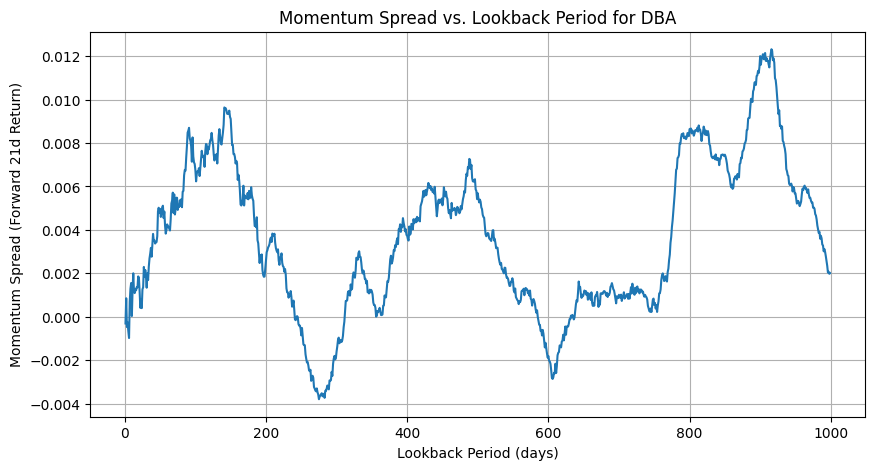

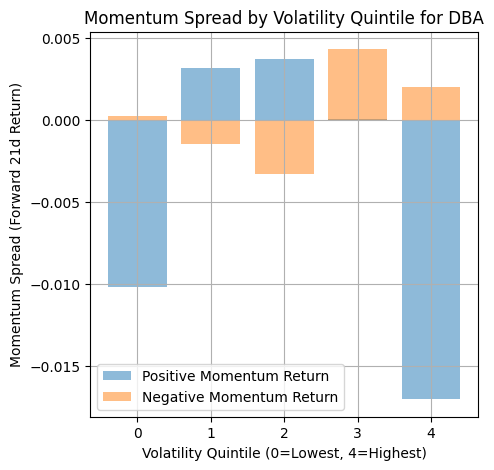

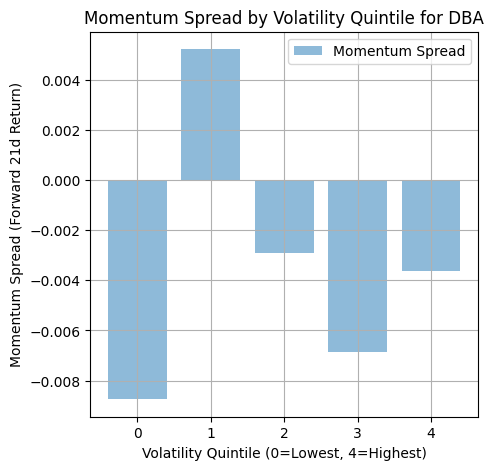

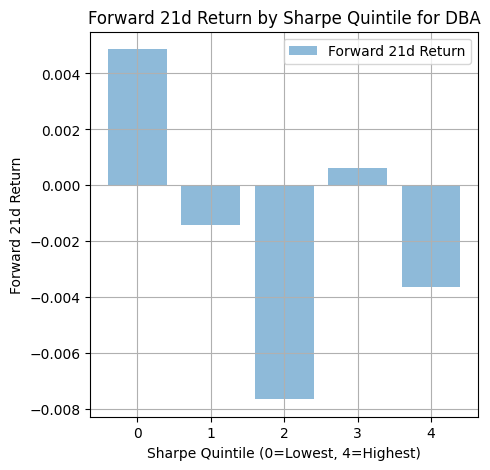

In [ ]:
def calculate_momentum(ticker, price_data):
    df = price_data[ticker].copy()
    
    # Forward 21 day log returns
    df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
    df['forward_21d_ret'] = df['log_ret'].rolling(window=21).sum().shift(-21)

    # Momentum period
    X = np.arange(1, 1000)
    y = []
    for x in tqdm(X):
        df['mom'] = df['close'].pct_change(periods=x)
        pos_mom_ret = df.loc[df['mom'] > 0, 'forward_21d_ret']
        neg_mom_ret = df.loc[df['mom'] <= 0, 'forward_21d_ret']
        
        spread = pos_mom_ret.mean() - neg_mom_ret.mean()
        y.append(spread)
    y = np.array(y)

    plt.figure(figsize=(10, 5))
    plt.plot(X, y)
    plt.title(f'Momentum Spread vs. Lookback Period for {ticker}')
    plt.xlabel('Lookback Period (days)')
    plt.ylabel('Momentum Spread (Forward 21d Return)')
    plt.grid()
    plt.show()

    # # Lag period
    # lookback = 252
    # X_lookback = [21, 100, 200, 252, 300, 400]
    # X_lag = np.arange(1, 100)
    # plt.figure(figsize=(10, 5))
    
    # for lookback in X_lookback:

    #     y = []
    #     for lag in X_lag:
    #         df['mom'] = df['close'].pct_change(periods=lookback).shift(lag)
    #         pos_mom_ret = df.loc[df['mom'] > 0, 'forward_21d_ret']
    #         neg_mom_ret = df.loc[df['mom'] <= 0, 'forward_21d_ret']
            
    #         spread = pos_mom_ret.mean() - neg_mom_ret.mean()
    #         y.append(spread)
    #     y = np.array(y)
    #     plt.plot(X_lag, y, label=f'Lookback: {lookback}d')
    # plt.title(f'Momentum Spread vs. Lag Period for {ticker}')
    # plt.xlabel('Lag Period (days)')
    # plt.ylabel('Momentum Spread (Forward 21d Return)')
    # plt.legend()
    # plt.grid()
    # plt.show()

    # Volatility filter
    lookback = 252
    lag = 21
    df['mom'] = df['close'].pct_change(periods=lookback).shift(lag)
    df['vol_21d'] = df['log_ret'].rolling(window=21).std().shift(1) * np.sqrt(252)
    
    # Split vol into quintiles and plot pos mom returns per quintile
    df['vol_quintile'] = pd.qcut(df['vol_21d'], 5, labels=False)
    vol_quintile_returns = []
    for quintile in range(5):
        df_subset = df[df['vol_quintile'] == quintile]
        pos_mom_ret = df_subset.loc[df_subset['mom'] > 0, 'forward_21d_ret']
        neg_mom_ret = df_subset.loc[df_subset['mom'] <= 0, 'forward_21d_ret']
        
        spread = pos_mom_ret.mean() - neg_mom_ret.mean()
        vol_quintile_returns.append((spread, pos_mom_ret.mean(), neg_mom_ret.mean()))
    plt.figure(figsize=(5, 5))
    # plt.bar(range(5), [f[0] for f in vol_quintile_returns], alpha=0.5, label='Momentum Spread')
    plt.bar(range(5), [f[1] for f in vol_quintile_returns], alpha=0.5, label='Positive Momentum Return')
    plt.bar(range(5), [f[2] for f in vol_quintile_returns], alpha=0.5, label='Negative Momentum Return')
    # plt.bar(range(5), vol_quintile_returns)
    plt.title(f'Momentum Spread by Volatility Quintile for {ticker}')
    plt.xlabel('Volatility Quintile (0=Lowest, 4=Highest)')
    plt.ylabel('Momentum Spread (Forward 21d Return)')
    plt.legend()
    plt.grid()
    plt.show()

    # Volatility diff filter
    lookback = 252
    lag = 21
    df['mom'] = df['close'].pct_change(periods=lookback).shift(lag)
    df['vol_21d'] = df['log_ret'].rolling(window=21).std().shift(1) * np.sqrt(252) / df['log_ret'].rolling(window=252).std().shift(1) * np.sqrt(252)
    
    # Split vol into quintiles and plot pos mom returns per quintile
    df['vol_quintile'] = pd.qcut(df['vol_21d'], 5, labels=False)
    vol_quintile_returns = []
    for quintile in range(5):
        df_subset = df[df['vol_quintile'] == quintile]
        pos_mom_ret = df_subset.loc[df_subset['mom'] > 0, 'forward_21d_ret']
        neg_mom_ret = df_subset.loc[df_subset['mom'] <= 0, 'forward_21d_ret']
        
        spread = pos_mom_ret.mean() - neg_mom_ret.mean()
        vol_quintile_returns.append((spread, pos_mom_ret.mean(), neg_mom_ret.mean()))
    plt.figure(figsize=(5, 5))
    plt.bar(range(5), [f[0] for f in vol_quintile_returns], alpha=0.5, label='Momentum Spread')
    # plt.bar(range(5), [f[1] for f in vol_quintile_returns], alpha=0.5, label='Positive Momentum Return')
    # plt.bar(range(5), [f[2] for f in vol_quintile_returns], alpha=0.5, label='Negative Momentum Return')
    # plt.bar(range(5), vol_quintile_returns)
    plt.title(f'Momentum Spread by Volatility Quintile for {ticker}')
    plt.xlabel('Volatility Quintile (0=Lowest, 4=Highest)')
    plt.ylabel('Momentum Spread (Forward 21d Return)')
    plt.legend()
    plt.grid()
    plt.show()

    # Sharpe filter
    lookback = 252
    lag = 21
    df['ret'] = df['log_ret'].rolling(window=lookback).sum()
    df['vol'] = df['log_ret'].rolling(window=lookback).std() * np.sqrt(252)
    df['sharpe'] = df['ret'] / df['vol']
    df['sharpe_quintile'] = pd.qcut(df['sharpe'], 5, labels=False)
    sharpe_quintile_returns = []
    for quintile in range(5):
        df_subset = df[df['sharpe_quintile'] == quintile]
        ret = df_subset['forward_21d_ret'].mean()
        
        
        sharpe_quintile_returns.append(ret)
    plt.figure(figsize=(5, 5))
    plt.bar(range(5), sharpe_quintile_returns, alpha=0.5, label='Forward 21d Return')
    plt.title(f'Forward 21d Return by Sharpe Quintile for {ticker}')
    plt.xlabel('Sharpe Quintile (0=Lowest, 4=Highest)')
    plt.ylabel('Forward 21d Return')
    plt.legend()
    plt.grid()

    return

for ticker in ['SPY', 'GLD', 'TLT', 'LQD', 'EEM', 'DBA']:
    calculate_momentum(ticker, price_data)

## Reallocation

Coefficient: -1.2132, Intercept: 0.0038, R^2: 0.0491
Coefficient: -0.6868, Intercept: 0.0037, R^2: 0.0505
Coefficient: -0.5264, Intercept: 0.0037, R^2: 0.0520
Coefficient: -0.4631, Intercept: 0.0037, R^2: 0.0536
Coefficient: -0.4468, Intercept: 0.0036, R^2: 0.0552
Coefficient: -0.4675, Intercept: 0.0036, R^2: 0.0569
Coefficient: -0.5363, Intercept: 0.0036, R^2: 0.0587
Coefficient: -0.7061, Intercept: 0.0036, R^2: 0.0605


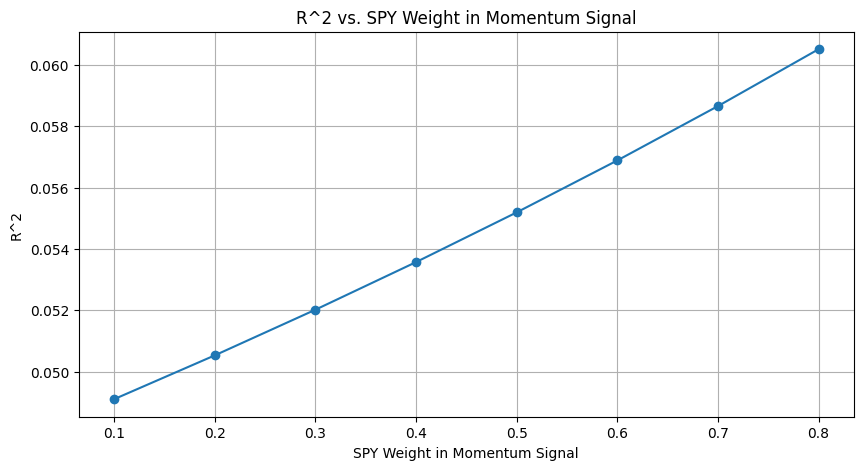

In [ ]:
def compute_spread(signal_w):
    lookback_period = 17
    forward_period = 5
    spy_df = price_data['SPY'].copy()
    tlt_df = price_data['IEF'].copy()

    df = spy_df[['close']].copy()
    df['spy_close'] = spy_df['close']
    df['tlt_close'] = tlt_df['close']
    df['spy_ret'] = np.log(df['spy_close'] / df['spy_close'].shift(1))
    df['tlt_ret'] = np.log(df['tlt_close'] / df['tlt_close'].shift(1))
    df['day'] = df.index.day
    df['day_of_week'] = df.index.dayofweek + 1
    df['spy_ret_lookback'] = df['spy_ret'].rolling(window=lookback_period).sum()
    df['tlt_ret_lookback'] = df['tlt_ret'].rolling(window=lookback_period).sum()
    df['spy_ret_forward'] = df['spy_ret'].rolling(window=forward_period).sum().shift(-forward_period)
    df['tlt_ret_forward'] = df['tlt_ret'].rolling(window=forward_period).sum().shift(-forward_period)
    df.dropna(inplace=True)
    df = df[3:]

    # display(df)

    signal_list = []
    ret_list = []
    counter = 0
    flag = False
    for i, r in df.iterrows():
        if r['day'] >= 22 and not flag:
            # print(i.date(), r['day'], r['day_of_week'])
            spy_ret = r['spy_ret_lookback']
            tlt_ret = r['tlt_ret_lookback']

            signal = signal_w * (1 + spy_ret) / ((signal_w) * (1 + spy_ret) + (1 - signal_w) * (1 + tlt_ret)) - signal_w
            signal_list.append(signal)

            ret_spread = r['spy_ret_forward'] - r['tlt_ret_forward']
            ret_list.append(ret_spread)
            flag = True
        if r['day'] < 25:
            flag = False
        counter += 1

    # plt.figure(figsize=(10, 5))
    # plt.scatter(signal_list, ret_list)
    # plt.title('SPY vs TLT Momentum Signal vs Forward Return Spread')
    # plt.xlabel('Momentum Signal (SPY 21d Return / TLT 21d Return)')
    # plt.ylabel('Forward 21d Return Spread (SPY - TLT)')
    # plt.grid()
    # plt.show()

    # coefficent and r2
    X = np.array(signal_list).reshape(-1, 1)
    y = np.array(ret_list)
    reg = LinearRegression().fit(X, y)
    r2 = reg.score(X, y)
    print(f'Coefficient: {reg.coef_[0]:.4f}, Intercept: {reg.intercept_:.4f}, R^2: {r2:.4f}')

    return reg.coef_[0], r2

X = np.arange(0.1, 0.9, 0.1)
y = []
for x in X:
    coeff, r2 = compute_spread(x)
    y.append(r2)
plt.figure(figsize=(10, 5))
plt.plot(X, y, marker='o')
plt.title('R^2 vs. SPY Weight in Momentum Signal')
plt.xlabel('SPY Weight in Momentum Signal')
plt.ylabel('R^2')
plt.grid()
plt.show()

# Portfolio Settings

In [ ]:
# CORE PORTFOLIO
core_portfolio_ticker_list = [
    'CSPX.L',
    'LQD',
    'TLT',
    'EEM',
    'GLD',
]
core_portfolio_allocation = 0.5

SPY_mom_allocation = 0.1

leveraged_portfolio_orders = dict()
UPRO_vol_allocation = 0.2
SHNY_vol_allocation = 0.1


# STOCK-PICK PORTFOLIO
stock_pick_portfolio_ticker_list = [
    'URA', 
    'ETHA',
    'GOOG',
    'MSFT',
    'HOOD',
]
stock_pick_portfolio_allocation = 0.1

assert 0.99 < np.sum([
    core_portfolio_allocation,
    SPY_mom_allocation,
    UPRO_vol_allocation,
    SHNY_vol_allocation,
    stock_pick_portfolio_allocation,
]) < 1.01, "Allocations must sum to 1"

combined_target_allocation = dict()
combined_orders = dict()

with open('STATUS_leveraged_port.json', 'r') as f:
    status_data = json.load(f)
last_update_date = status_data['UPRO']['date']
days_since_update = days_difference(last_update_date, CURRENT_DATE)
if days_since_update < 25:
    raise ValueError(f"Data is up to date as of {last_update_date}. No need to run the script.")

ValueError: Data is up to date as of 2025-10-18. No need to run the script.

# CORE PORTFOLIO

## Allocation based on HRP

### Utility Function

In [ ]:
def allocation_func(
    ticker_list,
    data,
    historical_period, 
    current_date,
    covariance_matrix_lookback,
    verbose=False
):
    #################################################################
    # Correlation Optimization
    # Use HRP to optimize for correlation between assets
    #################################################################
    
    df_combined = pd.DataFrame()
    for ticker in ticker_list:
        df_data = data[ticker].copy()
        df_data = df_data[df_data.index <= current_date].copy()
        df_data = df_data.iloc[-historical_period:]
        df_data['returns'] = df_data['close'].pct_change()
        df_combined[ticker] = df_data['returns']
    df_combined.dropna(inplace=True)

    # Covariance Matrix with Exponentially Weighted Moving Average
    ewma_cov = risk_models.exp_cov(df_combined, returns_data=True, span=covariance_matrix_lookback)
    
    # Convariance Matrix with Ledoit Wolf shrinkage
    ledoit_wolf_cov = risk_models.CovarianceShrinkage(
        prices=df_combined.iloc[-covariance_matrix_lookback:], 
        returns_data=True
    ).ledoit_wolf()

    # Final Covariance Matrix is mean of EWMA and Ledoit Wolf
    cov = (ledoit_wolf_cov + ewma_cov) / 2

    # HRP to generate asset allocation weights
    hrpopt = HRPOpt(
        cov_matrix=cov
    )
    asset_allocation_weights = hrpopt.optimize()
    if verbose:
        for ticker in asset_allocation_weights:
            print(f"{ticker}: {asset_allocation_weights[ticker]:.2%}")
    

    


    #################################################################
    # Combination of all optimizations
    #################################################################
    final_weights = asset_allocation_weights

    return final_weights



### Get Allocation

In [ ]:
allocations = allocation_func(
    core_portfolio_ticker_list,
    price_data,
    historical_period=252*2, 
    current_date=CURRENT_DATE,
    covariance_matrix_lookback=COVAR_LOOKBACK_PERIOD,
    verbose=True,
)

allocations

CSPX.L: 16.15%
EEM: 10.58%
GLD: 8.66%
LQD: 46.75%
TLT: 17.86%


OrderedDict([('CSPX.L', np.float64(0.16150672493323875)),
             ('EEM', np.float64(0.10582151612154249)),
             ('GLD', np.float64(0.08655907043142942)),
             ('LQD', np.float64(0.46753394031758166)),
             ('TLT', np.float64(0.17857874819620767))])

### Allocate

In [ ]:
capital = core_portfolio_allocation * CURRENT_CAPITAL
core_portfolio_orders = dict()

for ticker in core_portfolio_ticker_list:
    print('-----------------------')
    print(ticker)

    # Current holding
    current_holding = current_holdings.get(ticker, 0)

    # Proposed capital
    capital_allocated = allocations[ticker] * capital
    
    current_price = price_data[ticker]['close'].iloc[-1]
    
    target_holding = int(capital_allocated / current_price)
    combined_target_allocation[ticker] = target_holding * current_price / CURRENT_CAPITAL

    # Proposed order
    target_order = int((target_holding - current_holding) * 0.75) + 1

    print(f"Capital_allocated = {capital_allocated:.2f} ({allocations[ticker]:.2%})")
    print(f"Target holding:   = {target_holding}      ({capital_allocated:.2f} / {current_price:.2f})")
    print(f"Target order:     = {target_order}     ({target_holding} - {current_holding})")

    core_portfolio_orders[ticker] = target_order
    combined_orders[ticker] = target_order
    


-----------------------
CSPX.L
Capital_allocated = 7526.54 (16.15%)
Target holding:   = 10      (7526.54 / 727.26)
Target order:     = 1     (10 - 10.0)
-----------------------
LQD
Capital_allocated = 21788.02 (46.75%)
Target holding:   = 193      (21788.02 / 112.72)
Target order:     = 10     (193 - 181.0)
-----------------------
TLT
Capital_allocated = 8322.13 (17.86%)
Target holding:   = 90      (8322.13 / 91.47)
Target order:     = 0     (90 - 92.0)
-----------------------
EEM
Capital_allocated = 4931.49 (10.58%)
Target holding:   = 89      (4931.49 / 55.10)
Target order:     = 1     (89 - 89.0)
-----------------------
GLD
Capital_allocated = 4033.83 (8.66%)
Target holding:   = 10      (4033.83 / 377.52)
Target order:     = -5     (10 - 18.0)


# LEVERAGED PORTFOLIO

## Processing

In [ ]:
import json

def rolling_percentile_rank(x):
    """Compute percentile rank of the last element within the window (excluding itself)."""
    if len(x) < 2:
        return np.nan
    current_val = x.iloc[-1]
    prev_vals = x.iloc[:-1]
    return (prev_vals < current_val).mean()

def process_data_for_leveraged_trades(
    lev_df,
    vix_df
):
    vix_df = vix_df.copy()
    df = lev_df.copy()
    df['returns'] = df['adjclose'].pct_change().fillna(0.0)
    df['cum_ret'] = df['adjclose'].expanding().apply(lambda x: x.iloc[-1] / x.iloc[0])
    df['drawdown'] = df['cum_ret'] / df['cum_ret'].cummax() - 1
    df['vix'] = vix_df['close']
    df['vix_change'] = df['vix'].rolling(21).apply(lambda x: x.iloc[-1] - x.iloc[0])
    df['vix_signal'] = (df['vix_change'].rolling(252).apply(rolling_percentile_rank) * 2).clip(lower=0, upper=1)
    
    with open('STATUS_leveraged_port.json', 'r') as f:
        status = json.load(f)
    return df, status
    
    

## UPRO

In [ ]:
ticker = "UPRO"
lev_df = price_data[ticker]
vix_df = price_data['^VIX']
df, status = process_data_for_leveraged_trades(lev_df, vix_df)

signal = df['vix_signal'].iloc[-1]
drawdown = df['drawdown'].iloc[-1]

if drawdown < -0.1 and (not status[ticker]['status']):
        signal = 0.5 * signal
        status[ticker]['status'] = True
else: 
    status[ticker]['status'] = False

print(status)

with open('STATUS_leveraged_port.json', 'w') as f:
    json.dump(status, f, indent=4)

display(df.tail(5))




capital = UPRO_vol_allocation * CURRENT_CAPITAL



print('-----------------------')
print(ticker)

# Current holding
current_holding = current_holdings.get(ticker, 0)

# Proposed capital
capital_allocated = df['vix_signal'].iloc[-1] * capital

current_price = price_data[ticker]['close'].iloc[-1]

target_holding = int(capital_allocated / current_price) * signal

# Proposed order
target_order = target_holding - current_holding

print(f"Capital_allocated = {capital_allocated:.2f} ({df['vix_signal'].iloc[-1]:.2%})")
print(f"Target holding:   = {target_holding}      ({capital_allocated:.2f} / {current_price:.2f})")
print(f"Target order:     = {target_order}     ({target_holding} - {current_holding})")

leveraged_portfolio_orders[ticker] = target_order
combined_target_allocation[ticker] = target_holding * current_price / CURRENT_CAPITAL
combined_orders[ticker] = target_order


{'UPRO': {'status': False, 'date': '2025-10-18'}, 'SHNY': {'status': True, 'date': '2025-10-28'}}


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,cum_ret,drawdown,vix,vix_change,vix_signal
Date,,,,,,,,,,,,,,,
2025-10-20,111.089996,113.510002,111.070000,113.050003,113.050003,3365400,0.0,0.0,0.0,0.031102,99.329765,-0.015072,18.230000,2.129999,1.0
2025-10-21,113.110001,113.879997,112.370003,113.019997,113.019997,3153800,0.0,0.0,0.0,-0.000265,99.303401,-0.015334,17.870001,1.230001,1.0
2025-10-22,113.349998,113.349998,108.980003,111.230003,111.230003,5975300,0.0,0.0,0.0,-0.015838,97.730649,-0.030929,18.600000,2.420000,1.0
2025-10-23,111.330002,113.639999,111.199997,113.099998,113.099998,3158600,0.0,0.0,0.0,0.016812,99.373693,-0.014637,17.299999,0.559999,1.0
2025-10-24,115.449997,116.470001,115.050003,115.760002,115.760002,3591200,0.0,0.0,0.0,0.023519,101.710867,0.000000,16.370001,1.080001,1.0


-----------------------
UPRO
Capital_allocated = 18640.80 (100.00%)
Target holding:   = 161.0      (18640.80 / 115.76)
Target order:     = -6.0     (161.0 - 167.0)


## SHNY TRADE

In [ ]:
ticker = "SHNY"
lev_df = price_data[ticker]
vix_df = price_data['^GVZ']
df, status = process_data_for_leveraged_trades(lev_df, vix_df)

signal = df['vix_signal'].iloc[-1]
drawdown = df['drawdown'].iloc[-1]

if drawdown < -0.1 and (not status[ticker]['status']):
        signal = 0.5 * signal
        status[ticker]['status'] = True
else: 
    status[ticker]['status'] = False

print(status)

with open('STATUS_leveraged_port.json', 'w') as f:
    json.dump(status, f, indent=4)

display(df.tail(5))




capital = SHNY_vol_allocation * CURRENT_CAPITAL


print('-----------------------')
print(ticker)

# Current holding
current_holding = current_holdings.get(ticker, 0)

# Proposed capital
capital_allocated = df['vix_signal'].iloc[-1] * capital

current_price = price_data[ticker]['close'].iloc[-1]

target_holding = int(capital_allocated / current_price) * signal

# Proposed order
target_order = target_holding - current_holding

print(f"Capital_allocated = {capital_allocated:.2f} ({df['vix_signal'].iloc[-1]:.2%})")
print(f"Target holding:   = {target_holding}      ({capital_allocated:.2f} / {current_price:.2f})")
print(f"Target order:     = {target_order}      ({target_holding} - {current_holding})")

leveraged_portfolio_orders[ticker] = target_order
combined_target_allocation[ticker] = target_holding * current_price / CURRENT_CAPITAL
combined_orders[ticker] = target_order


{'UPRO': {'status': False, 'date': '2025-10-18'}, 'SHNY': {'status': True, 'date': '2025-10-28'}}


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,cum_ret,drawdown,vix,vix_change,vix_signal
Date,,,,,,,,,,,,,,,
2025-10-20,142.789993,148.750000,140.399994,148.589996,148.589996,355900,0.0,0.0,0.0,0.107228,6.047619,0.000000,31.430000,13.000000,1.0
2025-10-21,130.339996,132.949997,118.650002,120.650002,120.650002,663100,0.0,0.0,0.0,-0.188034,4.910460,-0.188034,29.820000,10.760000,1.0
2025-10-22,115.629997,121.110001,112.000000,120.010002,120.010002,408200,0.0,0.0,0.0,-0.005305,4.884412,-0.192341,27.190001,8.890001,1.0
2025-10-23,123.910004,124.930000,121.209999,121.430000,121.430000,185200,0.0,0.0,0.0,0.011832,4.942206,-0.182785,26.680000,7.610001,1.0
2025-10-24,121.070000,122.940002,119.570000,119.940002,119.940002,155800,0.0,0.0,0.0,-0.012270,4.881563,-0.192812,24.750000,6.160000,1.0


-----------------------
SHNY
Capital_allocated = 9320.40 (100.00%)
Target holding:   = 38.5      (9320.40 / 119.94)
Target order:     = -30.5      (38.5 - 69.0)


# MOMENTUM TRADE

In [ ]:
def process_data_for_momentum_trades(
    df
):
    # Calculate indicators
    df['returns'] = df['adjclose'].pct_change().fillna(0.0)
    df['cum_returns'] = (1 + df['returns']).cumprod() - 1
    df['vol_21'] = df['returns'].rolling(window=21).std() * np.sqrt(252)
    df['roll_returns_252'] = df['returns'].rolling(window=252).apply(lambda x: np.prod(x + 1)) - 1
    df['roll_returns_lag_21'] = df['roll_returns_252'].shift(21)
    df['mom_signal'] = np.where(df['roll_returns_lag_21'] > 0, 1.0, 0.2)
    df['mom_signal'] = df['mom_signal'].fillna(1.0)
    df['drawdown'] = (df['cum_returns'] - df['cum_returns'].cummax()) / df['cum_returns'].cummax()

    df = df.copy()
    return df

ticker = "SPY"
df = price_data[ticker].copy()
df = process_data_for_momentum_trades(df)
display(df.tail(5))

capital = SPY_mom_allocation * CURRENT_CAPITAL
momentum_portfolio_orders = dict()
print('-----------------------')
print(ticker)
# Current holding
current_holding = current_holdings.get(ticker, 0)
# Proposed capital
capital_allocated = df['mom_signal'].iloc[-1] * capital
current_price = price_data[ticker]['close'].iloc[-1]
target_holding = int(capital_allocated / current_price)
# Proposed order
target_order = target_holding - current_holding
print(f"Capital_allocated = {capital_allocated:.2f} ({df['mom_signal'].iloc[-1]:.2%})")
print(f"Target holding:   = {target_holding}      ({capital_allocated:.2f} / {current_price:.2f})")
print(f"Target order:     = {target_order}      ({target_holding} - {current_holding})")
momentum_portfolio_orders[ticker] = target_order
combined_target_allocation[ticker] = target_holding * current_price / CURRENT_CAPITAL
combined_orders[ticker] = target_order
    

,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,cum_returns,vol_21,roll_returns_252,roll_returns_lag_21,mom_signal,drawdown
Date,,,,,,,,,,,,,,,,
2025-10-20,667.320007,672.210022,667.270020,671.299988,671.299988,60493400,0.0,0.0,0.0,0.010400,26.610700,0.132282,0.166858,0.196706,1.0,-0.002790
2025-10-21,671.440002,672.989990,669.979980,671.289978,671.289978,56249000,0.0,0.0,0.0,-0.000015,26.610288,0.131423,0.166740,0.205945,1.0,-0.002805
2025-10-22,672.000000,672.000000,663.299988,667.799988,667.799988,80564000,0.0,0.0,0.0,-0.005199,26.466744,0.131290,0.156227,0.179257,1.0,-0.008184
2025-10-23,668.119995,672.710022,667.799988,671.760010,671.760010,65604500,0.0,0.0,0.0,0.005930,26.629621,0.131984,0.164997,0.177540,1.0,-0.002081
2025-10-24,676.460022,678.469971,675.650024,677.250000,677.250000,74306200,0.0,0.0,0.0,0.008173,26.855425,0.132811,0.175142,0.169186,1.0,0.000000


-----------------------
SPY
Capital_allocated = 9320.40 (100.00%)
Target holding:   = 13      (9320.40 / 677.25)
Target order:     = -1.0      (13 - 14.0)


# STOCK PICK PORTFOLIO

In [ ]:

stock_pick_portfolio_orders = dict()
for ticker in stock_pick_portfolio_ticker_list:
    print('-----------------------')
    print(ticker)

    # Current holding
    current_holding = current_holdings.get(ticker, 0)

    # Proposed capital
    capital_allocated = capital * (1 / len(stock_pick_portfolio_ticker_list))

    current_price = price_data[ticker]['close'].iloc[-1]

    target_holding = int(capital_allocated / current_price)

    # Proposed order
    target_order = int((target_holding - current_holding) * 0.5)

    print(f"Capital_allocated = {capital_allocated:.2f} ({(1 / len(stock_pick_portfolio_ticker_list)):.2%})")
    print(f"Target holding:   = {target_holding}      ({capital_allocated:.2f} / {current_price:.2f})")
    print(f"Target order:     = {target_order}     ({target_holding} - {current_holding})")

    stock_pick_portfolio_orders[ticker] = target_order
    combined_target_allocation[ticker] = target_holding * current_price / CURRENT_CAPITAL
    combined_orders[ticker] = target_order

-----------------------
URA
Capital_allocated = 1331.49 (14.29%)
Target holding:   = 25      (1331.49 / 51.50)
Target order:     = -2     (25 - 29.0)
-----------------------
ETHA
Capital_allocated = 1331.49 (14.29%)
Target holding:   = 44      (1331.49 / 29.71)
Target order:     = 12     (44 - 20.0)
-----------------------
U
Capital_allocated = 1331.49 (14.29%)
Target holding:   = 35      (1331.49 / 37.29)
Target order:     = 3     (35 - 28.0)
-----------------------
OKLO
Capital_allocated = 1331.49 (14.29%)
Target holding:   = 9      (1331.49 / 136.05)
Target order:     = 0     (9 - 8.0)
-----------------------
GOOG
Capital_allocated = 1331.49 (14.29%)
Target holding:   = 5      (1331.49 / 260.51)
Target order:     = 1     (5 - 3.0)
-----------------------
MSFT
Capital_allocated = 1331.49 (14.29%)
Target holding:   = 2      (1331.49 / 523.61)
Target order:     = 0     (2 - 3.0)
-----------------------
HOOD
Capital_allocated = 1331.49 (14.29%)
Target holding:   = 9      (1331.49 / 139.

# OVERALL

In [ ]:
combined_orders = dict()

for ticker in core_portfolio_orders:
    combined_orders[ticker] = combined_orders.get(ticker, 0) + core_portfolio_orders[ticker]

for ticker in momentum_portfolio_orders:
    combined_orders[ticker] = combined_orders.get(ticker, 0) + momentum_portfolio_orders[ticker]

for ticker in leveraged_portfolio_orders:
    combined_orders[ticker] = combined_orders.get(ticker, 0) + leveraged_portfolio_orders[ticker]
    

for ticker in stock_pick_portfolio_orders:
    combined_orders[ticker] = combined_orders.get(ticker, 0) + stock_pick_portfolio_orders[ticker]

for ticker in current_holdings:
    if ticker not in combined_orders:
        combined_orders[ticker] = -current_holdings[ticker]

df_orders = pd.DataFrame.from_dict(combined_orders, orient='index', columns=['quantity'])
df_orders['price'] = [price_data[ticker]['close'].iloc[-1] for ticker in df_orders.index]
df_orders['value'] = df_orders['quantity'] * df_orders['price']
df_orders = df_orders[df_orders['quantity'] != 0]
df_orders['abs_value'] = df_orders['value'].abs()
df_orders.sort_values('abs_value', ascending=False, inplace=True)
display(df_orders)

df_target_alloc = pd.DataFrame.from_dict(combined_target_allocation, orient='index', columns=['target_allocation'])
df_target_alloc['current_allocation'] = [df_view.loc[ticker, 'value'] / CURRENT_CAPITAL if ticker in df_view.index else 0.0 for ticker in df_target_alloc.index]
df_target_alloc['difference'] = df_target_alloc['target_allocation'] - df_target_alloc['current_allocation']
df_target_alloc.sort_values('difference', ascending=False, inplace=True)
print(f"Sum of target allocation: {df_target_alloc['target_allocation'].sum():.2%}")
df_target_alloc

,quantity,price,value,abs_value
SHNY,-30.5,119.940002,-3658.170074,3658.170074
GLD,-5.0,377.519989,-1887.599945,1887.599945
LQD,10.0,112.720001,1127.200012,1127.200012
CSPX.L,1.0,727.260010,727.260010,727.260010
UPRO,-6.0,115.760002,-694.560013,694.560013
SPY,-1.0,677.250000,-677.250000,677.250000
ETHA,12.0,29.709999,356.519989,356.519989
GOOG,1.0,260.510010,260.510010,260.510010
U,3.0,37.290001,111.870003,111.870003
URA,-2.0,51.500000,-103.000000,103.000000


Sum of target allocation: 93.05%


,target_allocation,current_allocation,difference
LQD,0.233412,0.218900,0.014513
ETHA,0.014026,0.006375,0.007650
GOOG,0.013975,0.008385,0.005590
U,0.014003,0.011203,0.002801
HOOD,0.013498,0.011999,0.001500
OKLO,0.013137,0.011678,0.001460
CSPX.L,0.078029,0.078029,0.000000
EEM,0.052615,0.052615,0.000000
TLT,0.088326,0.090288,-0.001963
URA,0.013814,0.016024,-0.002210


In [ ]:
df_orders.index

Index(['GLD', 'LQD', 'CSPX.L', 'UPRO', 'ETHA', 'GOOG', 'SHNY', 'U', 'URA',
       'EEM'],
      dtype='object')